# BNP Paribas.

# Bussines Case Project 2025/2026

Group:V
   - Alano Gonçalves (20250457)
   - Catarina ()
   - João Carichas (20250507)
   - Marta Ribeiro ()
   - Nicole Nogeira()

# Index

- [1. Import](#import)
  - [1.1 Import libraries](#import-libraries)
  - [1.2 Import the dataset](#import-the-dataset)
- [2. Data Exploration](#data-Exploration)
  - [2.1 MetaData](#metadata)
  - [2.2 Analysing the Data](#Analysing-the-Data)
  - [2.3 Data Visualization](#Data-visualization)
  - [2.4 Correlation Check](#correlation-check)
- [3. Data Quality & Feature Engineering](#Data-Quality-&-Feature-Engineering)
  - [3.1 Data Quality](#Data-Quality)
  - [3.2 Feature Engineering](#Feature-Engineering)
- [4. Implications for Clustering](#Implications-for-Clustering)
  

<div class="alert alert-block alert-info">

<a class="anchor" id="1. Import">    </a>
# 1. Import
       
</div>


[Back to Index](#index)

<a class="anchor" id="1.1 Import Libraries">

## 1.1 Import Libraries
    
</a>

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
#from suport import *
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score    

<a class="anchor" id="1.2 Import the Dataset">

## 1.2 Import the Dataset
    
</a>

In [50]:
!pip install pandas pyarrow
!pip install fastparquet

In [51]:
file_path = r"C:\Users\nicol\OneDrive\Documents\MDSAA\Business Cases\Projeto BC\crc.parquet"

# Ler o ficheiro parquet
CRC = pd.read_parquet(file_path, engine="fastparquet")

In [52]:
file_path1 = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\BNP-Paribas\credscore.parquet"
CREDSCORE = pd.read_parquet(file_path1, engine="fastparquet")


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\alano\\Desktop\\Mestrado\\2- Semestre\\Busines case\\BNP\\Projeto GIt\\BNP-Paribas\\credscore.parquet'

In [ ]:
file_path2 = r"C:\Users\alano\Desktop\Mestrado\2- Semestre\Busines case\BNP\Projeto GIt\BNP-Paribas\fama.parquet"
FAMA = pd.read_parquet(file_path2, engine="fastparquet")

In [53]:
file_path = r"C:\Users\nicol\OneDrive\Documents\MDSAA\Business Cases\Projeto BC\bdoss.parquet"

# Ler o ficheiro parquet
BDOSS = pd.read_parquet(file_path, engine="fastparquet")

<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# 2. Data Exploration
       
</div>


[Back to Index](#index)

<a class="anchor" id="2.1 MetaData">

## 2.1 MetaData

<a class="anchor" id="2.2 Analysing the Data">

## 2.2 Analysing the Data
    
</a>

<a class="anchor" id="2.2.1 CRC">

## 2.2.1 CRC
    
</a>

 Metadata
- *Date_Obs*: Observation Date (MMYY).
- *MT_MENSAL*: Sum of monthly installments paid by the client.
- *COUNT_CL*: Consumer credit count.
- *COUNT_CP*: Credit card or revolving credit count.
- *COUNT_AUTO*:  Auto loan credit count.
- *COUNT_HT*: Mortgage credit count.
- *COUNT_CONEXO*: Connected credit count.
- *COUNT_OTHER*: Other credits count.
- *COUNT_TOTAL*: Total credits count.
- *MONTVENC_CL*:  Sum of overdue amounts in consumer credit. 
- *MONTVENC_CP*:  Sum of overdue amounts in credit card and revolving credit.
- *MONTVENC_AUTO*:  Sum of overdue amounts in auto loans.
- *MONTVENC_HT*:  Sum of overdue amounts in mortgages.
- *MONTABATV_CL*:  Sum of written-off amounts in consumer credit.
- *MONTABATV_CP*:  Sum of written-off amounts in credit card and revolving credit.
- *MONTABATV_AUTO*:  Sum of written-off amounts in auto loans.
- *MONTABATV_HT*:  Sum of written-off amounts in mortgages.
- *DIVIDAS_CL*:   Total consumer credit debt.
- *DIVIDAS_CP*:  Total credit card and revolving credit debt.
- *DIVIDAS_AUTO*: Total auto loan debt.
- *DIVIDAS_HT*: Total mortgage debt.

#### 2.2.1.1.1. Data Overview

In [ ]:
CRC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3034921 entries, 0 to 3034920
Data columns (total 22 columns):
 #   Column          Dtype         
---  ------          -----         
 0   CONTRIB         object        
 1   OBS_DATE        datetime64[ns]
 2   MT_MENSAL       float64       
 3   COUNT_CL        float64       
 4   COUNT_CP        float64       
 5   COUNT_AUTO      float64       
 6   COUNT_HT        float64       
 7   COUNT_CONEXO    float64       
 8   COUNT_OTHER     float64       
 9   COUNT_TOTAL     float64       
 10  MONTVENC_CL     float64       
 11  MONTVENC_CP     float64       
 12  MONTVENC_AUTO   float64       
 13  MONTVENC_HT     float64       
 14  MONTABATV_CL    float64       
 15  MONTABATV_CP    float64       
 16  MONTABATV_AUTO  float64       
 17  MONTABATV_HT    float64       
 18  DIVIDAS_CL      float64       
 19  DIVIDAS_CP      float64       
 20  DIVIDAS_AUTO    float64       
 21  DIVIDAS_HT      float64       
dtypes: datetime64[ns](

- The most important (serious ones) are the MONTABATV. If those variables are too high, the client is not trustworthy.
- It is normal for a client to have DIVIDAS, but is preferable if they reduce month to month.

In [ ]:
CRC.describe().round(2)

,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,...,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
count,3034921,1029718.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,...,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00,3034749.00
mean,2025-01-01 06:09:42.119141376,552.09,1.65,3.09,0.55,0.46,0.07,0.67,6.49,103.33,...,19.69,37.85,4.34,4.27,0.30,0.47,11438.98,2624.60,5403.67,30449.71
min,2023-12-31 00:00:00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2024-06-30 00:00:00,236.67,1.00,2.00,0.00,0.00,0.00,0.00,4.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,1128.30,132.84,0.00,0.00
50%,2024-12-31 00:00:00,446.60,1.00,3.00,0.00,0.00,0.00,0.00,6.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,6160.02,1133.66,0.00,0.00
75%,2025-06-30 00:00:00,724.99,2.00,4.00,1.00,1.00,0.00,1.00,8.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,15248.11,3219.76,8243.23,46515.51
max,2025-12-31 00:00:00,1224049.39,90.00,183.00,26.00,36.00,15.00,72.00,330.00,2923893.44,...,130756.11,807322.92,171424.67,62861.30,33127.84,288803.22,3194523.32,480181.93,514850.48,4582324.44
std,NaN,1736.58,1.65,2.41,0.76,0.73,0.30,0.88,4.07,2818.38,...,591.92,2541.25,285.17,209.89,59.54,211.27,17905.50,4414.23,9711.06,59607.22


In [ ]:
CRC.tail()

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,...,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
3034916,fffc5ec9541c7691c7759c637317530910cf44783e4209...,2025-12-31,NaN,3.0,4.0,1.0,1.0,0.0,2.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,11944.76,3285.33,2975.66,76534.61
3034917,fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc6...,2025-12-31,990.24,3.0,4.0,0.0,0.0,0.0,1.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,50534.29,1959.59,0.00,0.00
3034918,fffc991d73df732084dab58938d520b8a5d8712474fa53...,2025-12-31,NaN,0.0,2.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00
3034919,fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a...,2025-12-31,NaN,1.0,1.0,1.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2197.85,2213.10,18037.03,0.00
3034920,fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00...,2025-12-31,NaN,3.0,1.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,20193.99,3057.11,0.00,0.00


In [ ]:
CRC = CRC.sort_values(['CONTRIB', 'OBS_DATE'])

In [ ]:
#To each client, check the maximum and minimum number of each variable
CRC.groupby('CONTRIB').agg(['min', 'max'])

OBS_DATE             \
                                                          min        max   
CONTRIB                                                                    
00008246f87bcc3c17b90629bb183fe2e58795176310f01... 2023-12-31 2025-12-31   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349... 2023-12-31 2025-12-31   
0000f858346061c53064586a3347b34659565a6712d004e... 2023-12-31 2025-12-31   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6... 2023-12-31 2025-12-31   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd... 2023-12-31 2025-11-30   
...                                                       ...        ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67... 2023-12-31 2025-12-31   
fffc991d73df732084dab58938d520b8a5d8712474fa539... 2023-12-31 2025-12-31   
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9... 2023-12-31 2025-12-31   
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c... 2023-12-31 2025-12-31   
ffff943c736f98d4840f65328ba372a29689312dd781b43... 2023-12-31 2025-08-31   

                                                   MT_MENSAL           \
                                                         min      max   
CONTRIB                                                                 
00008246f87bcc3c17b90629bb183fe2e58795176310f01...       NaN      NaN   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349...    538.67   547.45   
0000f858346061c53064586a3347b34659565a6712d004e...       NaN      NaN   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6...    515.57   515.57   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd...       NaN      NaN   
...                                                      ...      ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67...    305.96  1031.51   
fffc991d73df732084dab58938d520b8a5d8712474fa539...       NaN      NaN   
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9...       NaN      NaN   
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c...       NaN      NaN   
ffff943c736f98d4840f65328ba372a29689312dd781b43...       NaN      NaN   

                                                   COUNT_CL       COUNT_CP  \
                                                        min   max      min   
CONTRIB                                                                      
00008246f87bcc3c17b90629bb183fe2e58795176310f01...      0.0   1.0      3.0   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349...      4.0  12.0      5.0   
0000f858346061c53064586a3347b34659565a6712d004e...      1.0   2.0      5.0   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6...      3.0   3.0      1.0   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd...      8.0  36.0      3.0   
...                                                     ...   ...      ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67...      1.0   3.0      2.0   
fffc991d73df732084dab58938d520b8a5d8712474fa539...      0.0   1.0      2.0   
fffd54b6dbb4cc001fb8ab52a905cff9bdbf14b747be9a9...      1.0   1.0      1.0   
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c...      2.0   3.0      1.0   
ffff943c736f98d4840f65328ba372a29689312dd781b43...      0.0   1.0      3.0   

                                                         COUNT_AUTO       ...  \
                                                     max        min  max  ...   
CONTRIB                                                                   ...   
00008246f87bcc3c17b90629bb183fe2e58795176310f01...   9.0        0.0  6.0  ...   
0000ab2116257783438c70ff85a3e98f2d4194ebe534349...  15.0        0.0  0.0  ...   
0000f858346061c53064586a3347b34659565a6712d004e...  10.0        1.0  2.0  ...   
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c6...   2.0        0.0  0.0  ...   
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd...  16.0        0.0  0.0  ...   
...                                                  ...        ...  ...  ...   
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67...   8.0        0.0  1.0  ...   
fffc991d73df732084dab58938d520b8a5d8712474fa539...   2.0      

In [ ]:
#how many months of data do we have per client
CRC['CONTRIB'].value_counts()

CONTRIB
000785e8aca11cecd0db680ef13a751aa97ccf322d033332c0a4aff8db6e868c    25
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b    25
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981    25
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297    25
0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed    25
                                                                    ..
9e8f09117f4ea75b219984761fbdf795ba8e49e669e3d8168f8130bd84bb1b08     1
9e997a7ba95af15492c406601b2973edadd506930affa825ea884cd8d066133a     1
9eaa8e8ad04d65875075ac51063d9e38f2d599fc08d8b6de1e9d802f28281549     1
9ea65350fcbfd95566703782a8e95043445e996aa9e550783c87c25c69d3ad14     1
76859523ebb3d71fa7a5aeb17a43970d0dde5a3800099131d24df5913bd660d3     1
Name: count, Length: 141663, dtype: int64

In [ ]:
pd.set_option('display.max_columns', None)
CRC.sort_values(by=['CONTRIB','OBS_DATE'], ascending=False)
CRC.head(26)

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2023-12-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6842.10,963.55,0.00,0.0
119091,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-01-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6782.21,2111.44,0.00,0.0
238477,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-02-29,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6721.85,312.81,0.00,0.0
357730,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-03-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6661.02,501.34,0.00,0.0
477210,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-04-30,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6599.72,997.36,0.00,0.0
597135,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-05-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6537.94,1067.19,0.00,0.0
717015,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-06-30,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8000.00,1729.30,0.00,0.0
837418,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-07-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8000.00,1729.30,0.00,0.0
957821,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-08-31,NaN,1.0,4.0,0.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8000.00,1729.30,0.00,0.0
1078224,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,2024-09-30,NaN,0.0,4.0,1.0,0.0,0.0,1.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,1.65,16000.00,0.0


In [ ]:
CRC['DIVIDAS_CL'].value_counts(dropna=False)

DIVIDAS_CL
0.00        567067
5000.00       4716
3000.00       2347
2500.00       2330
10000.00      2130
             ...  
55710.24         1
55039.82         1
54367.68         1
53693.79         1
54388.12         1
Name: count, Length: 1463522, dtype: int64

#### 2.2.1.1.2. Checking Duplicates

In [ ]:
#checking number of duplicates
CRC.duplicated().sum()

np.int64(0)

#### 2.2.1.1.3. Checking Missing Values

In [ ]:
#checking number of missing values
CRC.isna().sum()

CONTRIB                 0
OBS_DATE                0
MT_MENSAL         2005203
COUNT_CL              172
COUNT_CP              172
COUNT_AUTO            172
COUNT_HT              172
COUNT_CONEXO          172
COUNT_OTHER           172
COUNT_TOTAL           172
MONTVENC_CL           172
MONTVENC_CP           172
MONTVENC_AUTO         172
MONTVENC_HT           172
MONTABATV_CL          172
MONTABATV_CP          172
MONTABATV_AUTO        172
MONTABATV_HT          172
DIVIDAS_CL            172
DIVIDAS_CP            172
DIVIDAS_AUTO          172
DIVIDAS_HT            172
dtype: int64

In [ ]:
#checking umber of missing values in each column as a percentage
CRC.isna().sum()/len(CRC) * 100

CONTRIB            0.000000
OBS_DATE           0.000000
MT_MENSAL         66.071011
COUNT_CL           0.005667
COUNT_CP           0.005667
COUNT_AUTO         0.005667
COUNT_HT           0.005667
COUNT_CONEXO       0.005667
COUNT_OTHER        0.005667
COUNT_TOTAL        0.005667
MONTVENC_CL        0.005667
MONTVENC_CP        0.005667
MONTVENC_AUTO      0.005667
MONTVENC_HT        0.005667
MONTABATV_CL       0.005667
MONTABATV_CP       0.005667
MONTABATV_AUTO     0.005667
MONTABATV_HT       0.005667
DIVIDAS_CL         0.005667
DIVIDAS_CP         0.005667
DIVIDAS_AUTO       0.005667
DIVIDAS_HT         0.005667
dtype: float64

- MT_MENSAL tem bastantes missing values- provavelmente não é uma variavel que nos vá dar muita informação (mais de 66% é missing value)
- Todas as outras variaveis têm o mesmo numero de missing values que provavelmente pretence às mesmas linhas: pode ser removido

In [ ]:
CRC[CRC['COUNT_CL'].isna()]

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
120541,03371c474bc2eaf39d5a22222ca6b05a8751a77362b77f...,2024-01-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
479523,04ef89de7d33bab517a2cbdf332dc6bb77f3b8e2561e42...,2024-04-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
719547,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
839950,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
960353,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236966,fcd94d024706a8660a0579a5bfdd1ee254de51123ce35c...,2024-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
836676,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-06-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
957079,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-07-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1077482,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-08-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
CRC[CRC['COUNT_CP'].isna()]

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
120541,03371c474bc2eaf39d5a22222ca6b05a8751a77362b77f...,2024-01-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
479523,04ef89de7d33bab517a2cbdf332dc6bb77f3b8e2561e42...,2024-04-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
719547,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
839950,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-07-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
960353,055f3f85601c087a8344d754fb336a273b02e7457bc4a1...,2024-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236966,fcd94d024706a8660a0579a5bfdd1ee254de51123ce35c...,2024-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
836676,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-06-30,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
957079,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-07-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1077482,fe7365ef0214334307216c6e886136af21c0cbba0ccd9e...,2024-08-31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
CRC[CRC['CONTRIB'] == 'c7e93bc661a9d5329ea48d365935197aecff39161303b6bf625189371f7ac23c']

,CONTRIB,OBS_DATE,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
92851,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2023-12-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
212165,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-01-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
331418,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-02-29,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
450836,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-03-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
570663,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-04-30,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
690551,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-05-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
810839,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-06-30,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
931242,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-07-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1051645,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-08-31,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1172696,c7e93bc661a9d5329ea48d365935197aecff39161303b6...,2024-09-30,431.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


There are clients that do not have information about the all 25 months

#### 2.2.1.1.4. Checking Outliers

In [ ]:
metric_features= ['MT_MENSAL', 'COUNT_CL', 'COUNT_CP', 'COUNT_AUTO', 'COUNT_HT', 'COUNT_CONEXO', 'COUNT_OTHER', 'COUNT_TOTAL', 'MONTVENC_CL', 'MONTVENC_CP', 'MONTVENC_AUTO', 'MONTVENC_HT', 'MONTABATV_CL', 'MONTABATV_CP', 'MONTABATV_AUTO', 'MONTABATV_HT', 'DIVIDAS_CL', 'DIVIDAS_CP', 'DIVIDAS_AUTO', 'DIVIDAS_HT']

In [ ]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables' Box Plots (>0 only)"):
    
    n_rows = ceil(len(feats) / n_cols)
    
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )
    
    axes = axes.flatten()
    
    for i, feat in enumerate(feats):
        
        # Keep only values strictly greater than 0
        values = data[feat]
        values = values[(values > 0) & (values.notna())]
        
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i])
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no >0 values)", fontsize=10)
    
    # Remove unused subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

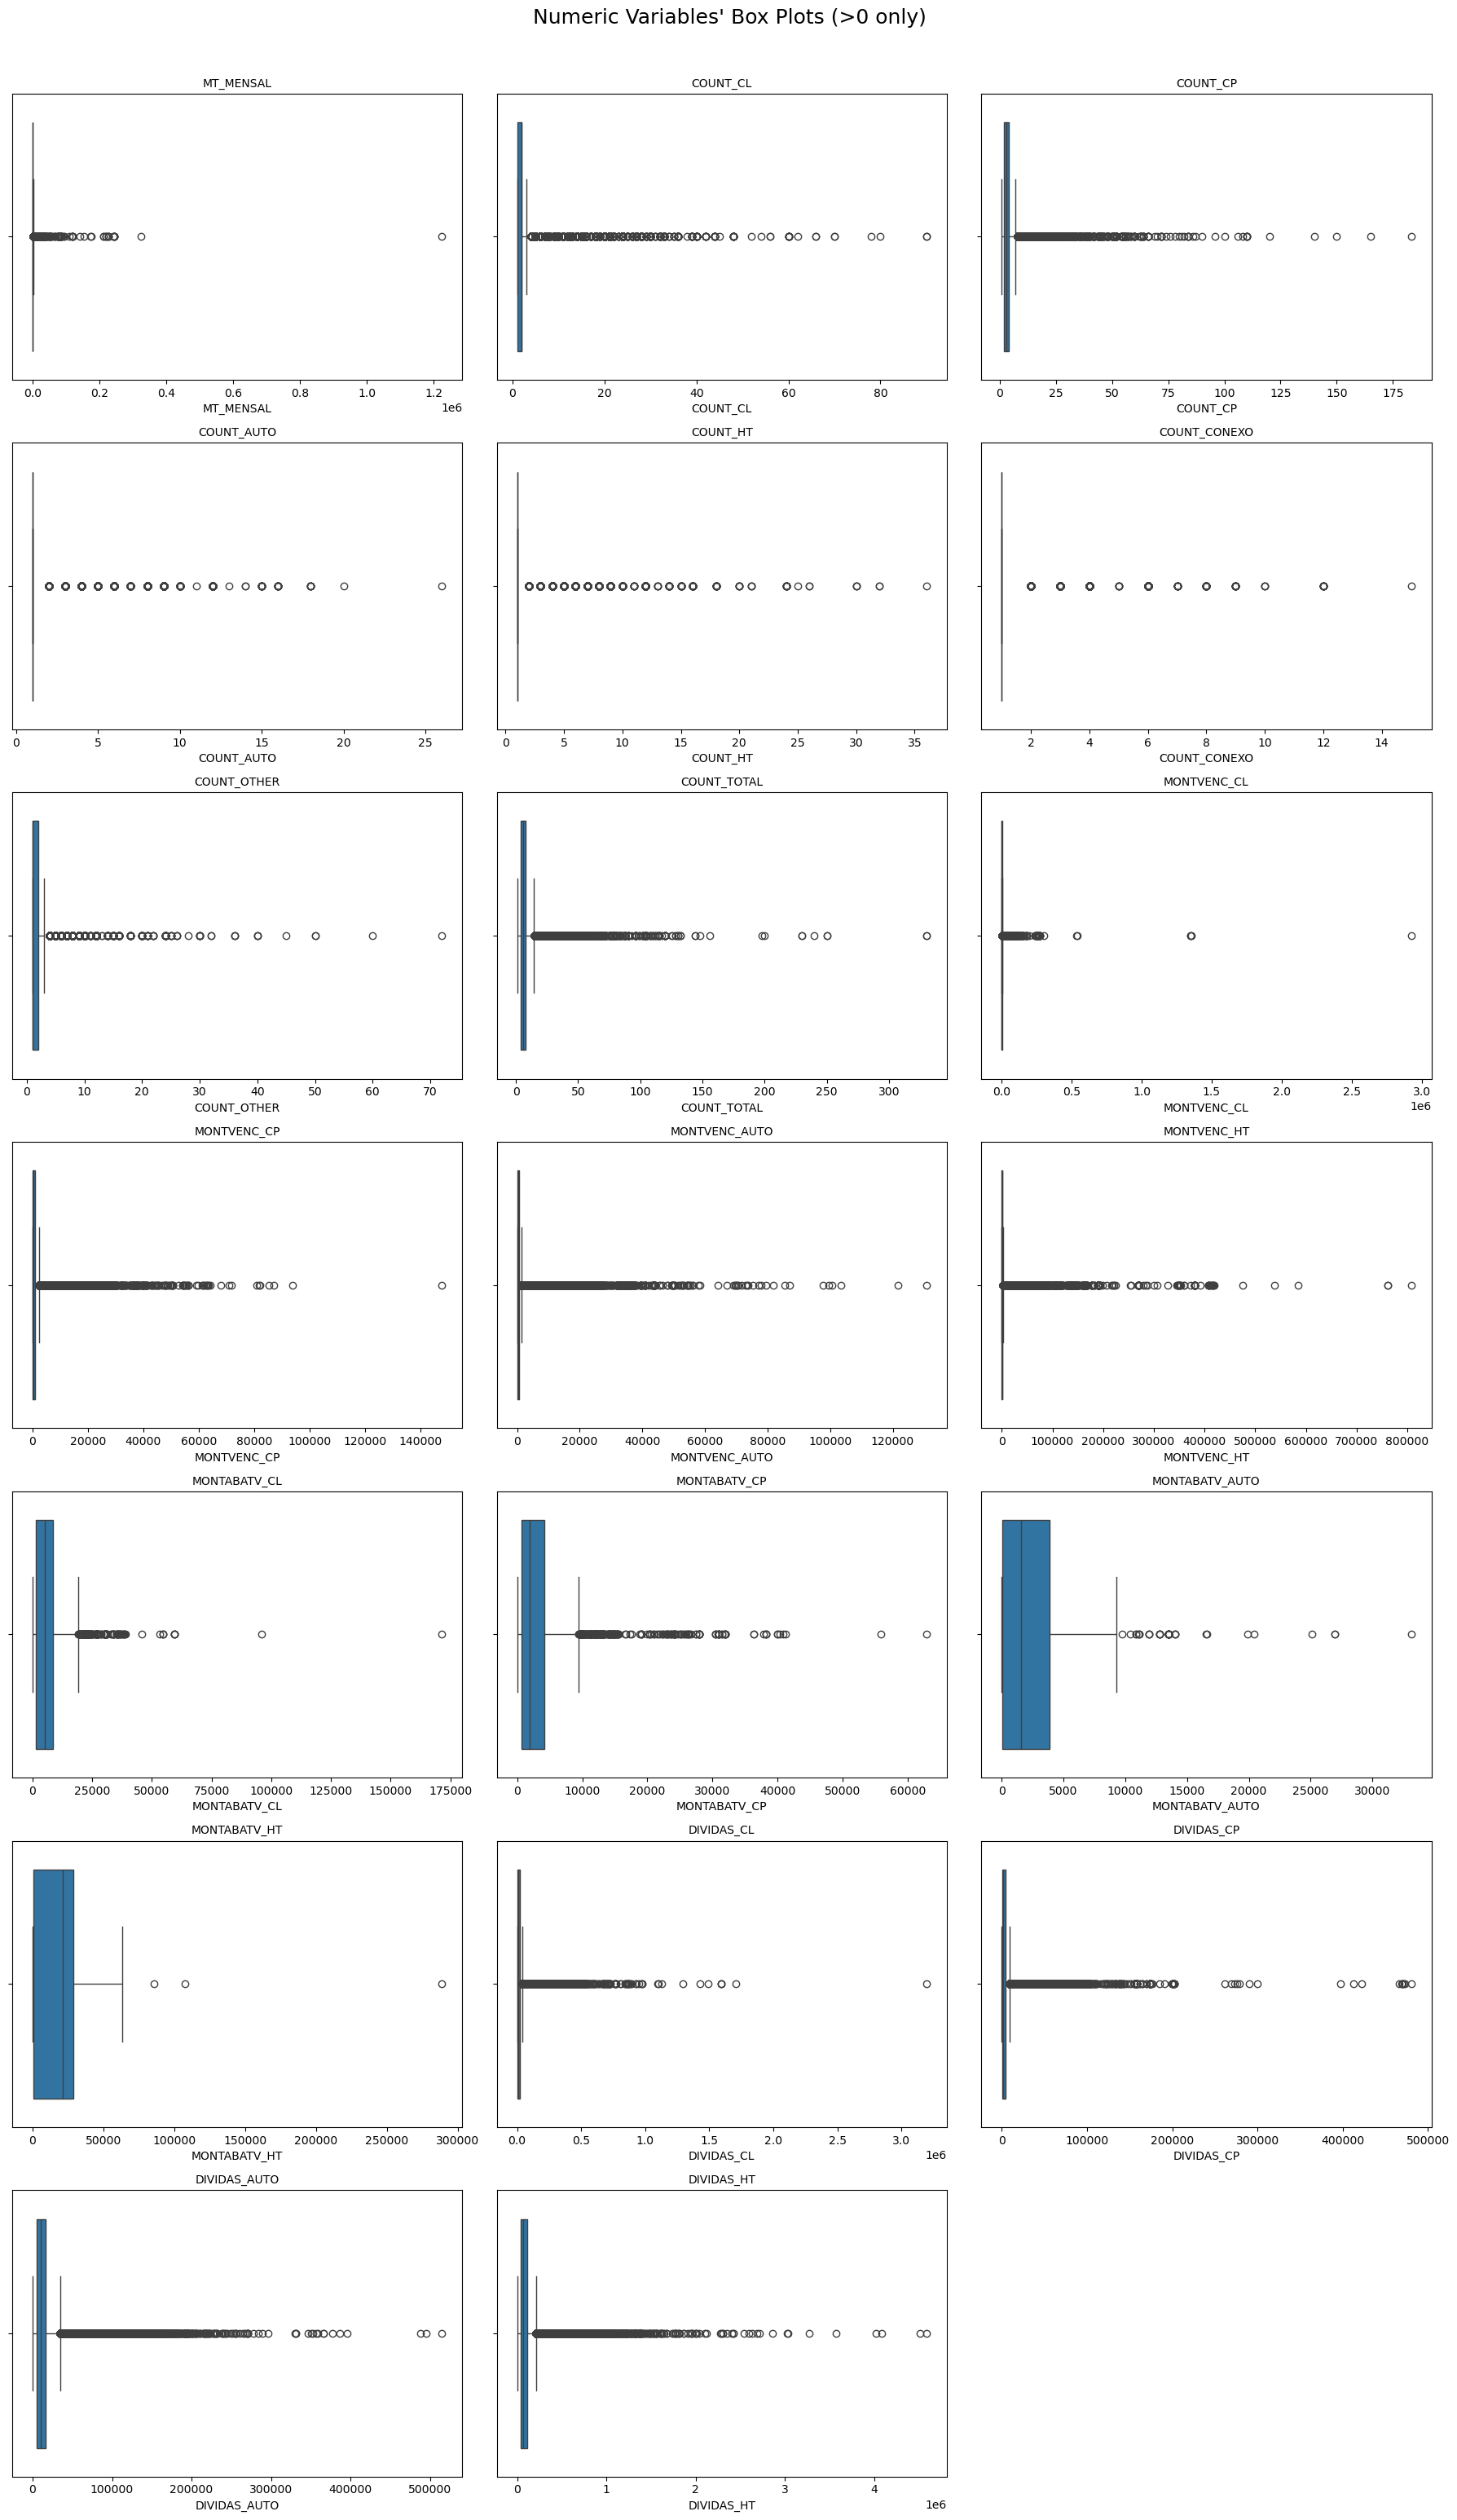

In [ ]:
#applying the function to our numerical features
plot_multiple_boxplots(CRC, metric_features)

In [ ]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables' Box Plots"):
    
    n_rows = ceil(len(feats) / n_cols)
    
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )
    
    axes = axes.flatten()  # flatten in case of multiple rows
    
    for i, feat in enumerate(feats):
        sns.boxplot(
            x=data[feat],
            ax=axes[i]
        )
        axes[i].set_title(feat, fontsize=10)
    
    # Remove empty subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

#### 2.2.1.1.5. Checking Distribution

In [ ]:
df= pd.DataFrame(CRC[metric_features])

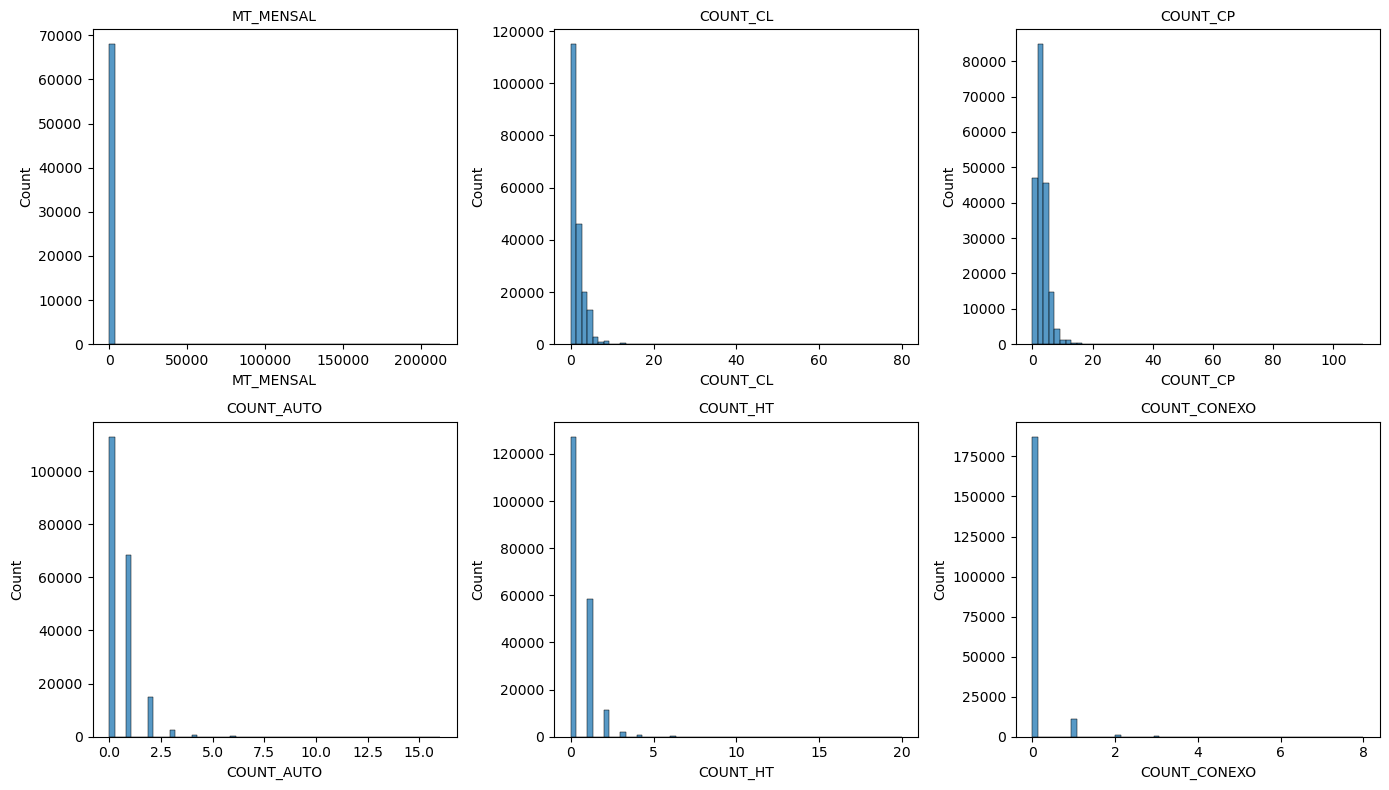

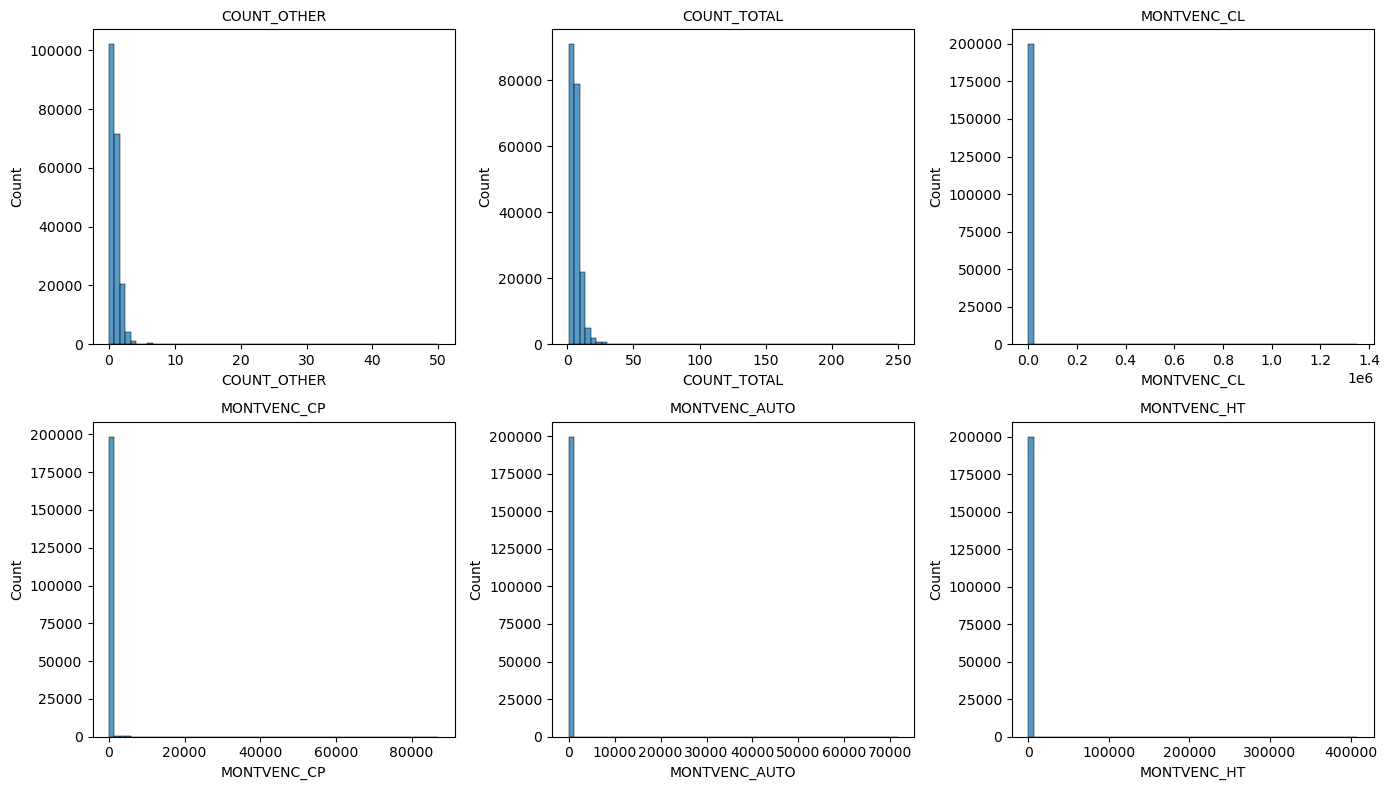

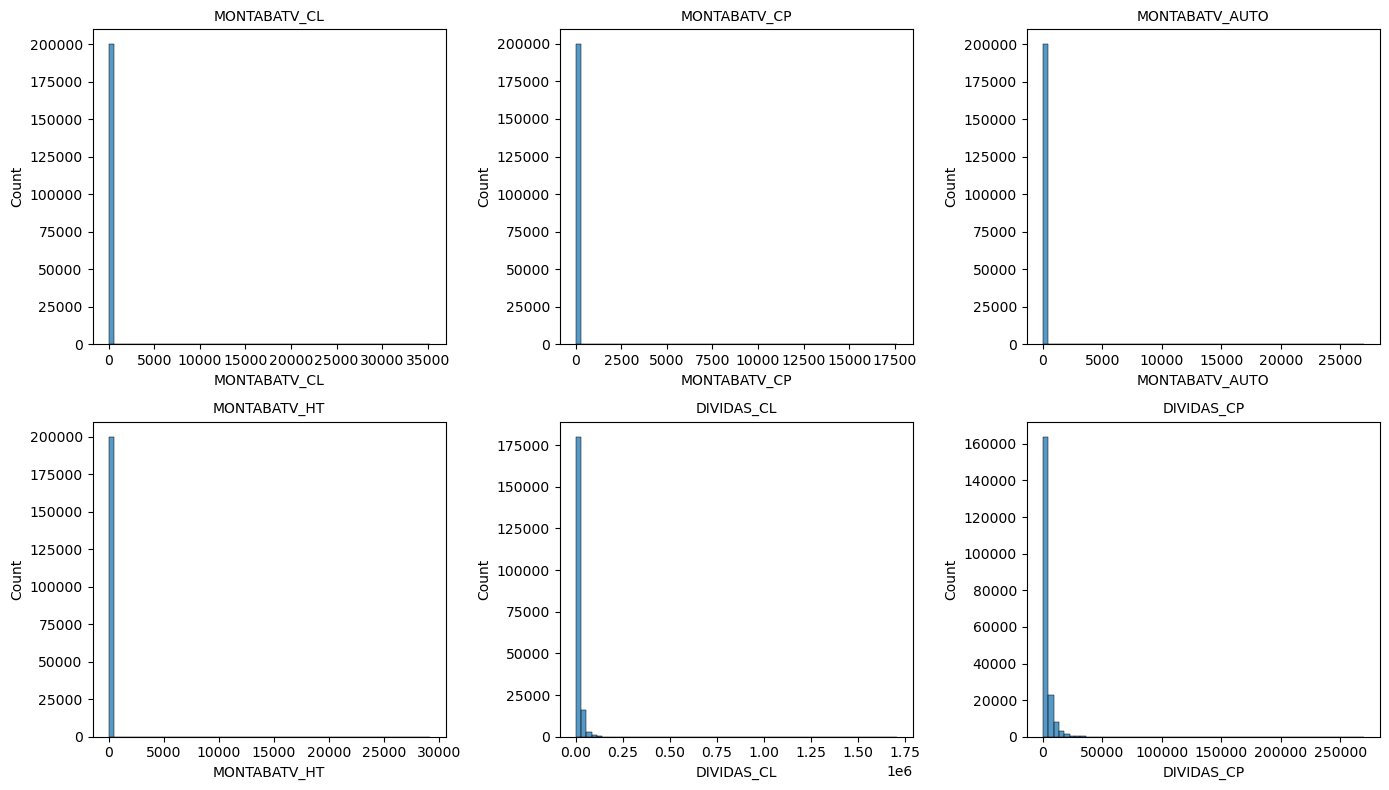

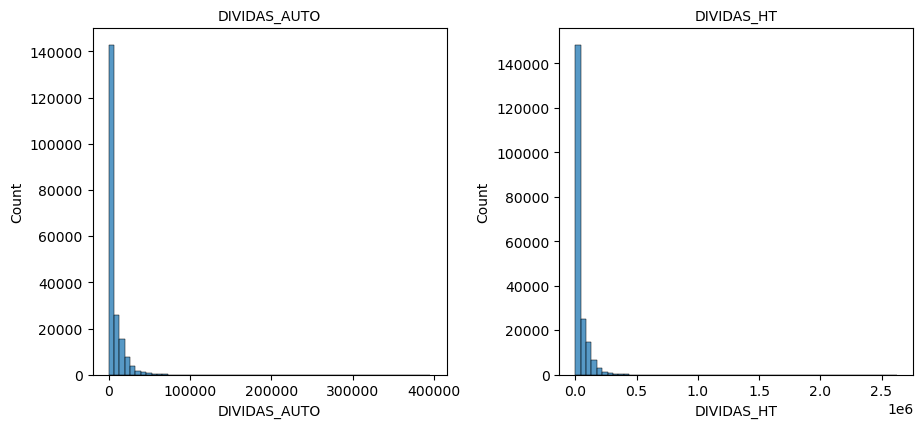

In [ ]:
# Sampling
N = 200_000
sample = CRC.sample(n=min(N, len(CRC)), random_state=42)

cols = sample.select_dtypes(include=[np.number]).columns  # all 20 variables

plots_per_fig = 6   # 2 rows x 3 cols
n_figs = ceil(len(cols) / plots_per_fig)

for f in range(n_figs):
    
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    for ax, col in zip(axes, subset_cols):
        sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax)
        ax.set_title(col, fontsize=10)
    
    # Remove empty subplots if last figure has fewer than 6 plots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

#### 2.2.1.1.6. Checking Correlation between variables

In [ ]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman = CRC[metric_features].corr(method ='spearman')
cor_spearman

,MT_MENSAL,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,MONTVENC_CL,MONTVENC_CP,MONTVENC_AUTO,MONTVENC_HT,MONTABATV_CL,MONTABATV_CP,MONTABATV_AUTO,MONTABATV_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT
MT_MENSAL,1.000000,0.395456,0.236308,0.231944,0.528161,0.272057,0.236045,0.558835,0.003648,-0.000568,0.016154,0.055819,-0.015057,-0.012127,-0.006622,-0.001455,0.533841,0.253331,0.266549,0.549654
COUNT_CL,0.395456,1.000000,0.204948,-0.183313,-0.006950,0.007571,0.086483,0.508537,0.166407,0.095022,0.025574,0.024357,0.022919,0.009356,-0.000684,0.000307,0.754133,0.321823,-0.153515,-0.014785
COUNT_CP,0.236308,0.204948,1.000000,-0.018989,0.130792,0.048963,0.223728,0.792283,-0.009487,0.065507,-0.021295,-0.004927,-0.006277,0.006749,-0.004314,-0.000484,0.197549,0.578446,-0.012727,0.122814
COUNT_AUTO,0.231944,-0.183313,-0.018989,1.000000,0.013875,0.015116,-0.035781,0.133008,-0.019078,-0.003135,0.136465,-0.001945,-0.001732,0.001956,0.011013,-0.003241,-0.231844,-0.033016,0.949972,0.016585
COUNT_HT,0.528161,-0.006950,0.130792,0.013875,1.000000,0.320383,0.221910,0.369609,-0.055014,-0.045006,-0.036792,0.113256,-0.009013,-0.011366,-0.005470,0.006431,0.014450,0.026859,0.011636,0.960529
COUNT_CONEXO,0.272057,0.007571,0.048963,0.015116,0.320383,1.000000,0.091806,0.195976,-0.018923,-0.018080,-0.010738,0.040709,-0.000477,-0.002240,-0.001672,-0.001178,0.017701,0.034912,0.012127,0.281941
COUNT_OTHER,0.236045,0.086483,0.223728,-0.035781,0.221910,0.091806,1.000000,0.464314,-0.006671,-0.008518,-0.019657,0.027521,-0.001341,0.000122,-0.001632,-0.001998,0.098743,0.129794,-0.035553,0.190432
COUNT_TOTAL,0.558835,0.508537,0.792283,0.133008,0.369609,0.195976,0.464314,1.000000,0.052153,0.069136,0.016794,0.041150,0.003689,0.006556,-0.001466,0.000327,0.398894,0.532123,0.133098,0.338988
MONTVENC_CL,0.003648,0.166407,-0.009487,-0.019078,-0.055014,-0.018923,-0.006671,0.052153,1.000000,0.464612,0.237175,0.113478,0.065208,0.077152,0.017712,0.007293,0.123688,0.078203,-0.017696,-0.055038
MONTVENC_CP,-0.000568,0.095022,0.065507,-0.003135,-0.045006,-0.018080,-0.008518,0.069136,0.464612,1.000000,0.230611,0.095578,0.050279,0.075669,0.011731,0.000846,0.074388,0.167852,-0.002428,-0.044053


In [ ]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap='YlGnBu',            #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

'''This function visualises a correlation matrix using a heatmap to
facilitate interpretation of relationships between variables. By 
masking the upper triangle of the matrix, the plot avoids redundant
information and improves the readability. '''

'This function visualises a correlation matrix using a heatmap to\nfacilitate interpretation of relationships between variables. By \nmasking the upper triangle of the matrix, the plot avoids redundant\ninformation and improves the readability. '

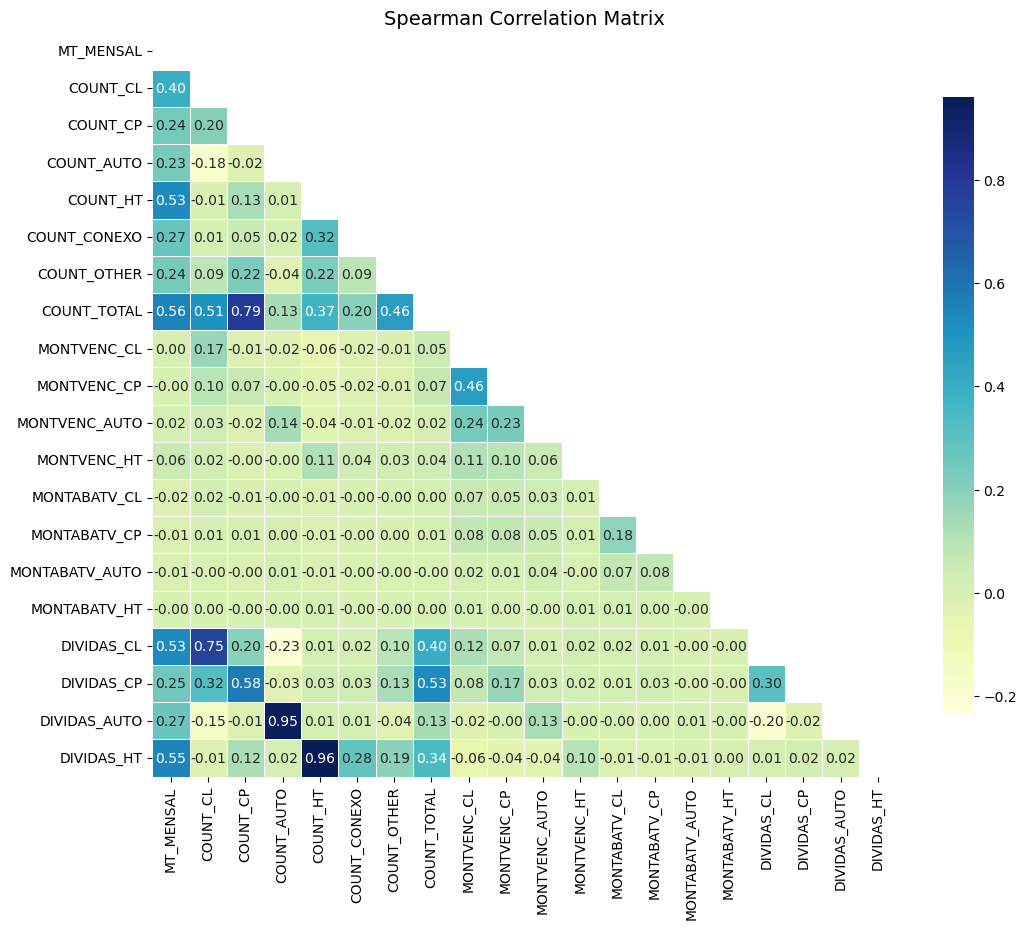

In [ ]:
#applying the function to our numerical features
cor_heatmap(cor_spearman)

In [ ]:
sns.set()

#creating a pairplot for numerical features
sns.pairplot(
    df[metric_features],
    diag_kind="hist"
)
#adjusting the layout and adding a title
plt.subplots_adjust(top=0.95)
plt.suptitle(
    "Pairwise Relationship of Numerical Variables",
    fontsize=20
)

#displaying the plot
plt.show()

KeyboardInterrupt: 

### 2.2.1.2. Data Preparation

In [ ]:
CRC.set_index('CONTRIB', inplace = True)

In [ ]:
#Changing Datatypes
CRC['COUNT_CL'] = CRC['COUNT_CL'].round().astype('Int32')
CRC['COUNT_CP'] = CRC['COUNT_CP'].round().astype('Int32')
CRC['COUNT_AUTO'] = CRC['COUNT_AUTO'].round().astype('Int32')
CRC['COUNT_HT'] = CRC['COUNT_HT'].round().astype('Int32')
CRC['COUNT_CONEXO'] = CRC['COUNT_CONEXO'].round().astype('Int32')
CRC['COUNT_OTHER'] = CRC['COUNT_OTHER'].round().astype('Int32')
CRC['COUNT_TOTAL'] = CRC['COUNT_TOTAL'].round().astype('Int32')

In [ ]:
#handling missing values of 172 rows
CRC = CRC.dropna(subset=['COUNT_CL'])

In [ ]:
#droping MT_MENSAL due to its elevated number of missing values
CRC = CRC.drop(columns=['MT_MENSAL'])

In [ ]:
#checking number of missing values
CRC.isna().sum()

OBS_DATE          0
COUNT_CL          0
COUNT_CP          0
COUNT_AUTO        0
COUNT_HT          0
COUNT_CONEXO      0
COUNT_OTHER       0
COUNT_TOTAL       0
MONTVENC_CL       0
MONTVENC_CP       0
MONTVENC_AUTO     0
MONTVENC_HT       0
MONTABATV_CL      0
MONTABATV_CP      0
MONTABATV_AUTO    0
MONTABATV_HT      0
DIVIDAS_CL        0
DIVIDAS_CP        0
DIVIDAS_AUTO      0
DIVIDAS_HT        0
dtype: int64

### 2.2.1.3. Feature Engineering

In [ ]:
CRC.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3034749 entries, 00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981 to ffff943c736f98d4840f65328ba372a29689312dd781b437624e6112d3d6803b
Data columns (total 20 columns):
 #   Column          Dtype         
---  ------          -----         
 0   OBS_DATE        datetime64[ns]
 1   COUNT_CL        Int32         
 2   COUNT_CP        Int32         
 3   COUNT_AUTO      Int32         
 4   COUNT_HT        Int32         
 5   COUNT_CONEXO    Int32         
 6   COUNT_OTHER     Int32         
 7   COUNT_TOTAL     Int32         
 8   MONTVENC_CL     float64       
 9   MONTVENC_CP     float64       
 10  MONTVENC_AUTO   float64       
 11  MONTVENC_HT     float64       
 12  MONTABATV_CL    float64       
 13  MONTABATV_CP    float64       
 14  MONTABATV_AUTO  float64       
 15  MONTABATV_HT    float64       
 16  DIVIDAS_CL      float64       
 17  DIVIDAS_CP      float64       
 18  DIVIDAS_AUTO    float64       
 19  DIVIDAS_HT 

In [ ]:
#creating 'MONTVENC_TOTAL'
CRC['MONTVENC_TOTAL'] = CRC[
    ['MONTVENC_CL','MONTVENC_CP','MONTVENC_AUTO','MONTVENC_HT']
].sum(axis=1)

In [ ]:
#creating 'MONTABATV_TOTAL'
CRC['MONTABATV_TOTAL'] = CRC[
    ['MONTABATV_CL','MONTABATV_CP','MONTABATV_AUTO','MONTABATV_HT']
].sum(axis=1)

In [ ]:
#has the client default history?
CRC['HIGH_RISK_CURRENT'] = (
    (CRC['MONTABATV_TOTAL'] > 0) | 
    (CRC['MONTVENC_TOTAL'] > 0)
).astype(int)

In [ ]:
CRC['BALANCE_CL'] = (CRC['MONTVENC_CL'] - CRC['MONTABATV_CL'])
CRC['BALANCE_CP'] = (CRC['MONTVENC_CP'] - CRC['MONTABATV_CP'])
CRC['BALANCE_AUTO'] = (CRC['MONTVENC_AUTO'] - CRC['MONTABATV_AUTO'])
CRC['BALANCE_HT'] = (CRC['MONTVENC_HT'] - CRC['MONTABATV_HT'])

cols_to_move = ['BALANCE_CL', 'BALANCE_CP', 'BALANCE_AUTO', 'BALANCE_HT']

for col in reversed(cols_to_move):
    col_data = CRC.pop(col)
    CRC.insert(10, col, col_data)

In [ ]:
CRC = CRC.drop(columns=['MONTVENC_CL', 'MONTABATV_CL', 'MONTVENC_CP', 'MONTABATV_CP', 'MONTVENC_AUTO', 'MONTABATV_AUTO', 'MONTVENC_HT', 'MONTABATV_HT', 'MONTVENC_TOTAL', 'MONTABATV_TOTAL'])

In [ ]:
pd.set_option('display.max_columns', None)
CRC = CRC.sort_values(['CONTRIB', 'OBS_DATE'])
CRC.tail(30)

,OBS_DATE,COUNT_CL,COUNT_CP,COUNT_AUTO,COUNT_HT,COUNT_CONEXO,COUNT_OTHER,COUNT_TOTAL,BALANCE_CL,BALANCE_CP,BALANCE_AUTO,BALANCE_HT,DIVIDAS_CL,DIVIDAS_CP,DIVIDAS_AUTO,DIVIDAS_HT,HIGH_RISK_CURRENT
CONTRIB,,,,,,,,,,,,,,,,,
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,2024-05-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,17345.04,3320.12,0.00,0.0,0
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,2024-06-30,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,17512.16,3244.15,0.00,0.0,0
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,2024-07-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,17512.16,3244.15,0.00,0.0,0
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,2024-08-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,17512.16,3244.15,0.00,0.0,0
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,2024-09-30,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,17218.32,3011.78,0.00,0.0,0
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,2024-10-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,17218.32,3011.78,0.00,0.0,0
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,2024-11-30,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,17143.40,3272.10,0.00,0.0,0
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,2024-12-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,17067.34,3158.29,0.00,0.0,0
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b,2025-01-31,2,1,0,0,0,0,3,0.00,0.00,0.00,0.0,16991.81,2885.36,0.00,0.0,0


In [ ]:
#aggregating CRC's variables 
CRC_agg = (
    CRC
    .groupby("CONTRIB", as_index=True)
    .agg(
        count_cl=("COUNT_CL", "last"),
        count_cp=("COUNT_CP", "last"),
        count_auto=("COUNT_AUTO", "last"),
        count_ht=("COUNT_HT", "last"),
        count_conexo=("COUNT_CONEXO", "last"),
        count_other=("COUNT_OTHER", "last"),
        balance_cl=("BALANCE_CL", "mean"),
        balance_cp=("BALANCE_CP", "mean"),
        balance_auto=("BALANCE_AUTO", "mean"),
        balance=("BALANCE_HT", "mean"),
        dividas_cl=("DIVIDAS_CL", "mean"),
        dividas_cp=("DIVIDAS_CP", "mean"),
        dividas_auto=("DIVIDAS_AUTO", "mean"),
        dividas_ht=("DIVIDAS_HT", "mean"),
    )
)

In [ ]:
CRC_agg.head()

,count_cl,count_cp,count_auto,count_ht,count_conexo,count_other,balance_cl,balance_cp,balance_auto,balance,dividas_cl,dividas_cp,dividas_auto,dividas_ht
CONTRIB,,,,,,,,,,,,,,
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,0,3,1,0,0,1,0.00000,0.000000,0.0,0.0,2565.793600,1150.592400,13479.8216,0.0000
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,4,5,0,0,0,1,0.00000,0.000000,0.0,0.0,26448.032000,7552.117200,0.0000,0.0000
0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed,1,5,1,1,0,0,0.00000,0.000000,0.0,0.0,2082.786000,1854.039600,1665.2756,88154.7832
00025459b703e1c308553e83a6d545a71fe6a787c2dd1c62d26faa0207cc5b08,3,2,0,0,0,1,0.00000,0.000000,0.0,0.0,22980.086400,102.284800,0.0000,0.0000
00041ebafb1270a818c30cb1fb20d3699002196644ea8fd9df9425df6f49db00,9,4,0,0,0,2,2416.34125,1622.499583,0.0,0.0,55289.663333,4865.075417,0.0000,0.0000


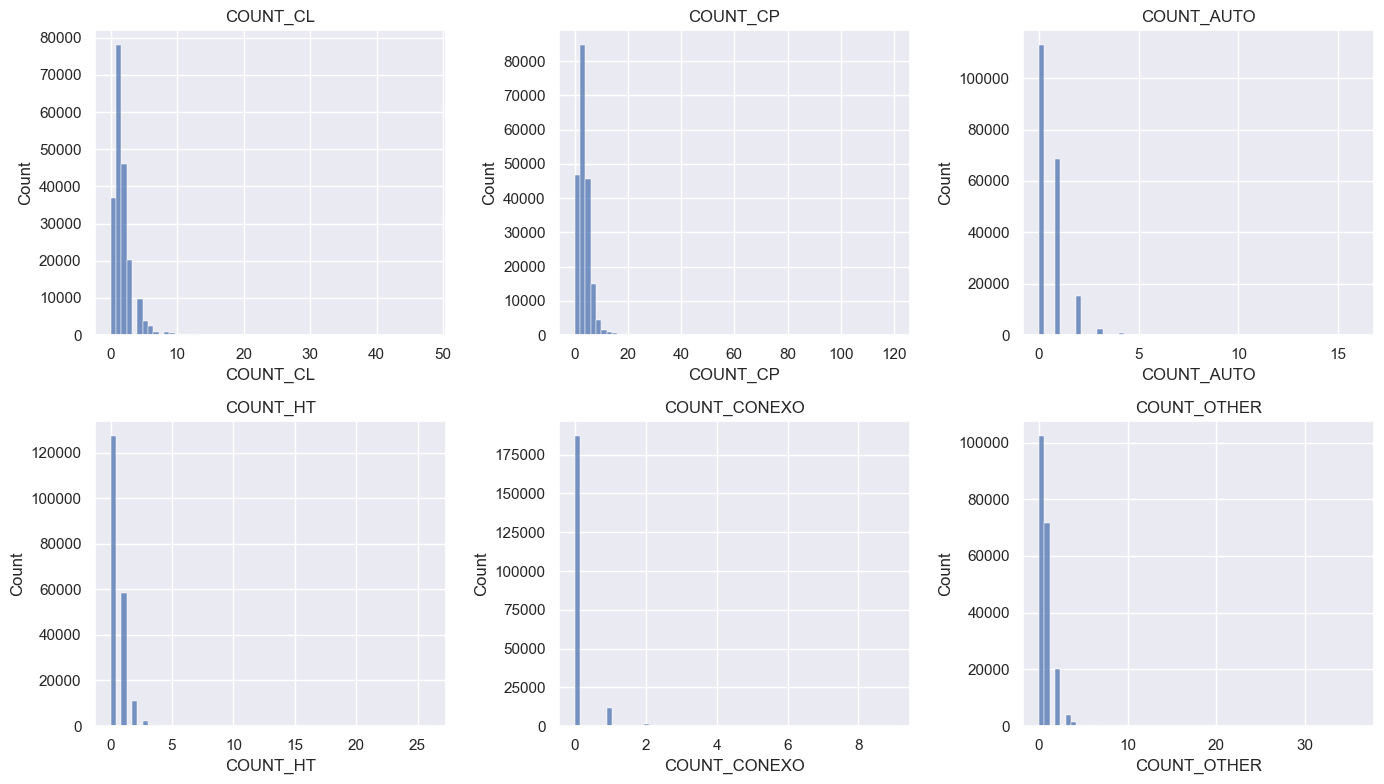

In [ ]:
numeric_cols = ['COUNT_CL', 'COUNT_CP', 'COUNT_AUTO', 'COUNT_HT', 'COUNT_CONEXO', 'COUNT_OTHER', 'COUNT_TOTAL', 'MONTVENC_CL', 'MONTVENC_CP', 'MONTVENC_AUTO', 'MONTVENC_HT', 
                'MONTABATV_CL', 'MONTABATV_CP', 'MONTABATV_AUTO', 'MONTABATV_HT', 'DIVIDAS_CL', 'DIVIDAS_CP', 'DIVIDAS_AUTO', 'DIVIDAS_HT']

N = 200_000 
sample = CRC.sample(n=min(N, len(CRC)), random_state=42) 
cols = numeric_cols[:6] 

fig, axes = plt.subplots(2, 3, figsize=(14, 8)) 
axes = axes.ravel() 
for ax, col in zip(axes, cols): 
    sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax) 
    ax.set_title(col) 

plt.tight_layout() 
plt.show()

KeyError: 'MONTVENC_CL'

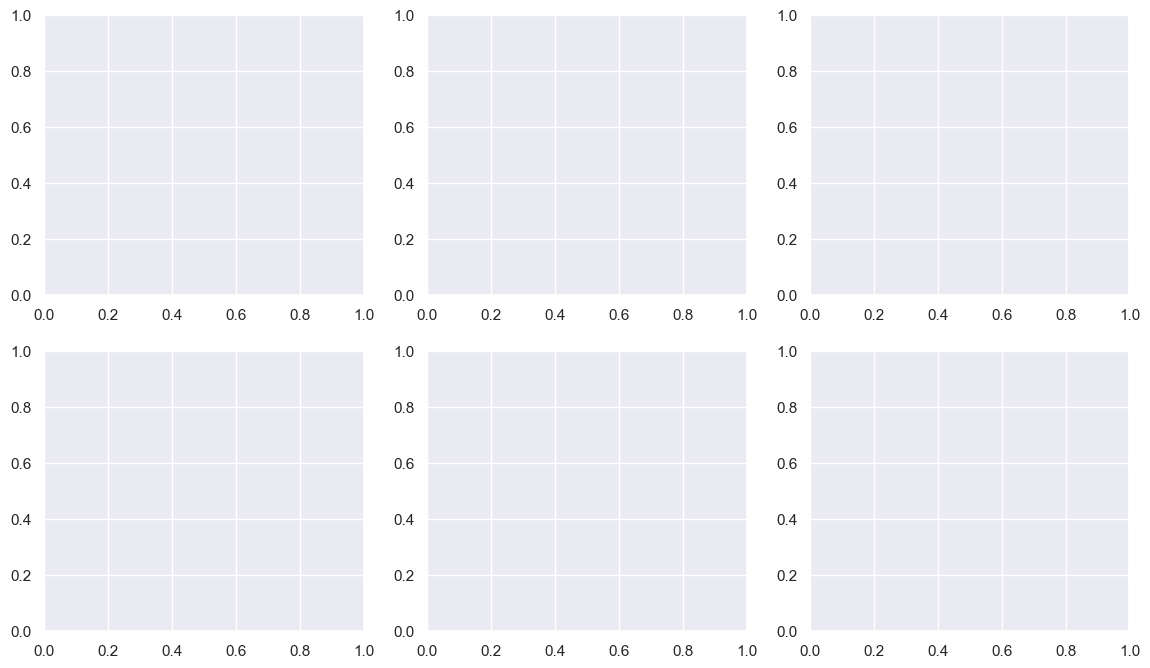

In [ ]:
N = 200_000 
sample = CRC.sample(n=min(N, len(CRC)), random_state=42) 
cols = numeric_cols[7:13] 

fig, axes = plt.subplots(2, 3, figsize=(14, 8)) 
axes = axes.ravel() 
for ax, col in zip(axes, cols): 
    sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax) 
    ax.set_title(col) 

plt.tight_layout() 
plt.show()

KeyError: 'MONTABATV_HT'

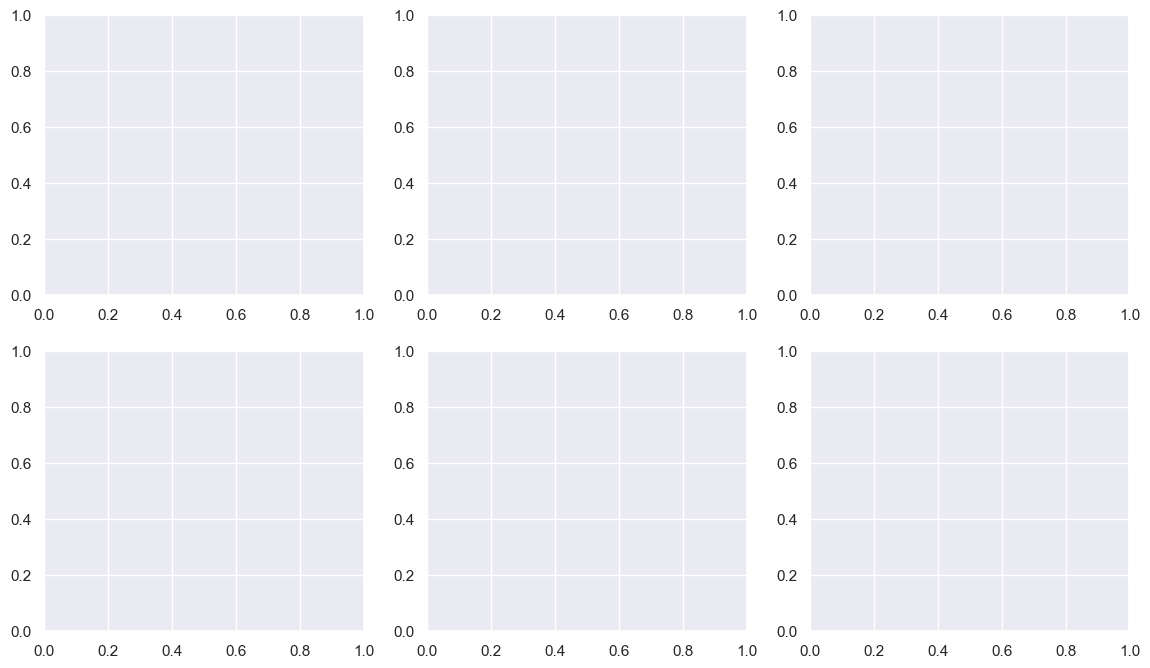

In [ ]:
N = 200_000 
sample = CRC.sample(n=min(N, len(CRC)), random_state=42) 
cols = numeric_cols[14:20] 

fig, axes = plt.subplots(2, 3, figsize=(14, 8)) 
axes = axes.ravel() 
for ax, col in zip(axes, cols): 
   sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax) 
   ax.set_title(col) 

plt.tight_layout() 
plt.show()

In [ ]:
corr = CRC.corr(numeric_only=True)

mask = (corr.abs() < 0.5)

plt.figure(figsize=(12,8))
sns.heatmap(corr, 
            mask=mask, 
            annot=True, 
            cmap="Blues", 
            center=0)

plt.title("Correlation")
plt.show()

<a class="anchor" id="2.2.2 CREDSCORE">

## 2.2.2 CREDSCORE
    
</a>

<a class="anchor" id="2.2.3 FAMA">

## 2.2.3 FAMA
    
</a>

In [ ]:
pd.set_option('display.max_columns', None)
FAMA.head()

,CONTRIB,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_MTFIN_CL__N,ALLBD_MTFIN_CP__N,ALLBD_IDADE_MSA__N,ALLBD_IDADE_MIN__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,31f4b2a40e2cc73faf9cf16c7bd6ebeea6f322931d4e0b...,2024-11-30,15.0,6.0,9.0,1.0,0.0,88784.04,0.00,88784.040000,0.0,4443.0,-808.0,1280.533333,0.0,1153.000000,1153.0,120.0,0.425000,15.0,C,P,62
1,bb7bc8dfa33e27eb832f58210a2d3282839cd2a8e7f420...,2024-11-30,6.0,4.0,2.0,1.0,2.0,9584.91,7628.41,9584.910000,0.0,3120.0,-2077.0,466.333333,14.0,1564.666667,1582.0,72.0,0.138889,6.0,C,A,65
2,a377de96fc89a1aabdb5e25682e54c7d02a7209c7246d0...,2024-11-30,8.0,5.0,3.0,1.0,0.0,22000.86,0.00,22000.860000,0.0,4936.0,-2089.0,907.625000,0.0,1765.000000,1765.0,36.0,0.277778,8.0,C,L,65
3,9e4d032b84105ac4981257fc993ed33f60dfec1542c723...,2024-11-30,3.0,3.0,0.0,1.0,0.0,10384.00,0.00,10384.000000,0.0,2882.0,-2096.0,301.000000,0.0,840.000000,840.0,72.0,0.138889,3.0,V,P,69
4,7d0cb0079863cbf9d6d179491aab944c9af7e988d1e4bc...,2024-11-30,9.0,8.0,1.0,1.0,0.0,12866.23,0.00,13756.584246,0.0,8629.0,-1063.0,2267.555556,0.0,3268.000000,3268.0,48.0,0.916667,9.0,C,A,68


In [ ]:
FAMA.describe().T

,count,mean,min,25%,50%,75%,max,std
Date_Obs,141115,2024-11-30 00:00:00,2024-11-30 00:00:00,2024-11-30 00:00:00,2024-11-30 00:00:00,2024-11-30 00:00:00,2024-11-30 00:00:00,NaN
ALLBD_N_Dossiers__N,141115.0,8.569727,1.0,4.0,7.0,11.0,136.0,6.21527
ALLBD_N_CL__N,141115.0,5.796868,0.0,3.0,5.0,8.0,91.0,4.768982
ALLBD_N_CP__N,141115.0,2.772859,0.0,1.0,2.0,4.0,81.0,2.302179
ALLBD_A_CL__N,141115.0,0.782319,0.0,0.0,1.0,1.0,7.0,0.61869
ALLBD_A_CP__N,141115.0,0.682911,0.0,0.0,1.0,1.0,9.0,0.79483
ALLBD_MTFINO_CL__N,141115.0,17305.858039,0.0,5000.0,11000.0,22324.89,436815.12,19565.305925
ALLBD_MTFINO_CP__N,141115.0,2890.91579,0.0,0.0,0.0,3187.78,322929.95,6739.935575
ALLBD_MTFIN_CL__N,141115.0,17459.8429,0.0,5000.0,11000.0,22500.0,996095.0,20332.811246
ALLBD_MTFIN_CP__N,141115.0,83.288209,-2649.0,0.0,0.0,9.485,8574.36,289.391822


## Neste dataset vamos olhar para o historico do cliente e nao para o que esta ativo.

In [ ]:
drop=['ALLBD_A_CL__N','ALLBD_A_CP__N','ALLBD_MTFIN_CL__N','ALLBD_MTFIN_CP__N']
drop1=['ALLBD_IDADE_MSA__N','ALLBD_IDADE_MIN__N']
FAMA= FAMA.drop(columns=drop1, errors='ignore')

In [ ]:
FAMA.head()

,CONTRIB,Date_Obs,ALLBD_N_Dossiers__N,ALLBD_N_CL__N,ALLBD_N_CP__N,ALLBD_A_CL__N,ALLBD_A_CP__N,ALLBD_MTFINO_CL__N,ALLBD_MTFINO_CP__N,ALLBD_IDADE_MEAN__N,ALLBD_SUM_NUMFIN_CP__N,ALLBD_mean_active_resso__N,ALLBD_max_active_resso__N,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age
0,31f4b2a40e2cc73faf9cf16c7bd6ebeea6f322931d4e0b...,2024-11-30,15.0,6.0,9.0,1.0,0.0,88784.04,0.00,1280.533333,0.0,1153.000000,1153.0,120.0,0.425000,15.0,C,P,62
1,bb7bc8dfa33e27eb832f58210a2d3282839cd2a8e7f420...,2024-11-30,6.0,4.0,2.0,1.0,2.0,9584.91,7628.41,466.333333,14.0,1564.666667,1582.0,72.0,0.138889,6.0,C,A,65
2,a377de96fc89a1aabdb5e25682e54c7d02a7209c7246d0...,2024-11-30,8.0,5.0,3.0,1.0,0.0,22000.86,0.00,907.625000,0.0,1765.000000,1765.0,36.0,0.277778,8.0,C,L,65
3,9e4d032b84105ac4981257fc993ed33f60dfec1542c723...,2024-11-30,3.0,3.0,0.0,1.0,0.0,10384.00,0.00,301.000000,0.0,840.000000,840.0,72.0,0.138889,3.0,V,P,69
4,7d0cb0079863cbf9d6d179491aab944c9af7e988d1e4bc...,2024-11-30,9.0,8.0,1.0,1.0,0.0,12866.23,0.00,2267.555556,0.0,3268.000000,3268.0,48.0,0.916667,9.0,C,A,68


In [ ]:
x = (FAMA['ALLBD_mean_active_resso__N'] != FAMA['ALLBD_max_active_resso__N']).mean() * 100
x

np.float64(21.01973567657584)

<a class="anchor" id="2.2.4 BDOSS">

## 2.2.4 BDOSS
    
</a>

In [ ]:
pd.set_option('display.max_columns', None)
BDOSS.head()

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
0,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,P,CL,EP,0.0,ENC,2024-01-31,2018-03-29,2018-04-16,2018-04-16,2018-04-16,120.0,69.0,69.0,20000.0,20000.0,347.447280,NaN,13208.455,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,1113.258,80.0,1988.0,P,2845,1.0,A
1,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,P,CL,EP,0.0,SAN,2024-01-31,2019-01-28,2019-02-04,2019-02-04,2022-12-28,72.0,34.0,34.0,2500.0,2500.0,56.017772,NaN,0.000,0.000,NaN,1.0,1.0,000000000000210210000110,0.0,120.0,N,838.186,91.0,1990.0,P,2855,0.0,A
2,0000f858346061c53064586a3347b34659565a6712d004...,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e71751456...,P,CL,EP,0.0,ENC,2024-01-31,2019-09-23,2019-09-30,2019-09-30,2019-09-30,84.0,52.0,52.0,5000.0,5000.0,100.073575,NaN,2665.191,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,1314.144,80.0,2013.0,P,2635,2.0,W
3,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,446d96905d26356fb4f1d3e1e6da3868b8106b09a558e6...,P,CL,EPF,0.0,ENC,2024-01-31,2023-01-09,2023-01-13,2023-01-13,2023-01-13,60.0,13.0,37.0,6000.0,6000.0,162.097525,NaN,5893.092,0.000,NaN,0.0,0.0,000000000000000000000000,0.0,117.0,P,1031.650,80.0,1989.0,P,5090,0.0,A
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6...,N,CL,EXT,0.0,ENC,2024-01-31,2021-02-10,2021-02-17,2021-02-17,2024-01-31,84.0,32.0,32.0,20500.0,20500.0,463.755537,NaN,17844.618,-463.756,NaN,2.0,4.0,000000000000000002112122,0.0,119.0,P,1113.258,80.0,2019.0,P,2835,0.0,A


In [ ]:
BDOSS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658187 entries, 0 to 2658186
Data columns (total 35 columns):
 #   Column             Dtype         
---  ------             -----         
 0   CONTRIB            object        
 1   DOSSIER            object        
 2   POLE               object        
 3   TYPEPROD           object        
 4   PRODALP            object        
 5   BICONTRATO         float64       
 6   POS                object        
 7   OBS_DATE           datetime64[ns]
 8   DCREAT             datetime64[ns]
 9   DATFIN             datetime64[ns]
 10  D1FIN              datetime64[ns]
 11  DPOS               datetime64[ns]
 12  DURDEG             float64       
 13  RANGPRO            float64       
 14  RANGCLI            float64       
 15  MTFINO             float64       
 16  MTFIN              float64       
 17  MENSALIDADE        float64       
 18  MENSALIDADE_CORR   float64       
 19  CRD                float64       
 20  SREC               float

In [54]:
BDOSS['BICONTRATO'] = BDOSS['BICONTRATO'].round().astype('Int32')
BDOSS['DURDEG'] = BDOSS['DURDEG'].round().astype('Int32')
BDOSS['RANGPRO'] = BDOSS['RANGPRO'].round().astype('Int32')
BDOSS['RANGCLI'] = BDOSS['RANGCLI'].round().astype('Int32')
BDOSS['RISKA'] = BDOSS['RISKA'].round().astype('Int32')

In [55]:
BDOSS.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
CONTRIB,2658187,148729,364aad4f1733591b129753f295cca317a449f207c209bd...,158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DOSSIER,2658187,185592,f8908577ee5bab0f764f1f007f439370b0511585b89d96...,46,NaN,NaN,NaN,NaN,NaN,NaN,NaN
POLE,2658187,2,P,2615205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TYPEPROD,2658187,1,CL,2658187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PRODALP,2658187,4,EP,1912612,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BICONTRATO,2658187.0,<NA>,<NA>,<NA>,0.0,0.0,0.0,0.0,0.0,0.0,0.0
POS,2658187,4,ENC,2214397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OBS_DATE,2658187,NaN,NaN,NaN,2024-12-31 12:04:59.079635456,2024-01-31 00:00:00,2024-06-30 00:00:00,2024-12-31 00:00:00,2025-06-30 00:00:00,2025-11-30 00:00:00,NaN
DCREAT,2658187,NaN,NaN,NaN,2022-03-23 09:42:27.446511104,1996-06-14 00:00:00,2020-11-24 00:00:00,2022-10-20 00:00:00,2024-01-31 00:00:00,2025-12-02 00:00:00,NaN
DATFIN,2658187,NaN,NaN,NaN,2022-04-01 11:27:02.187001088,1996-06-17 00:00:00,2020-12-02 00:00:00,2022-10-28 00:00:00,2024-02-07 00:00:00,2025-12-02 00:00:00,NaN


## **Data exploration:**

**- Duplicates**

In [56]:
BDOSS.duplicated().sum()

np.int64(0)

**- Missing Values**

In [57]:
BDOSS.isna().sum()[BDOSS.isna().sum() > 0]

RANGCLI                    1
MENSALIDADE_CORR     2658187
ACTIVIDADE_GLOBAL    2658187
DCSP                  293663
NATIO                      1
NBENF                    736
MODCONTACTO            59544
dtype: int64

In [58]:
#checking umber of missing values in each column as a percentage
BDOSS.isna().sum()[BDOSS.isna().sum() > 0]/len(BDOSS) * 100

RANGCLI                0.000038
MENSALIDADE_CORR     100.000000
ACTIVIDADE_GLOBAL    100.000000
DCSP                  11.047492
NATIO                  0.000038
NBENF                  0.027688
MODCONTACTO            2.240023
dtype: float64

**- Constant Features**

In [59]:
BDOSS['MENSALIDADE_CORR'].unique()

array([nan])

In [60]:
BDOSS['ACTIVIDADE_GLOBAL'].unique()

array([nan])

In [61]:
BDOSS['TYPEPROD'].unique()

array(['CL'], dtype=object)

In [62]:
BDOSS['BICONTRATO'].unique()

<IntegerArray>
[0]
Length: 1, dtype: Int32

---

In [ ]:
BDOSS['RISK'].value_counts()

In [ ]:
BDOSS['RISKA'].value_counts()

In [ ]:
BDOSS['NBENF'].value_counts() #valores outliers

In [ ]:
BDOSS['AGFIN'].value_counts()

In [ ]:
BDOSS['POS'].unique()

In [ ]:
BDOSS['POS'].value_counts()

apenas queremos P?

In [ ]:
BDOSS['POLE'].value_counts()

nenhum deles aparece no metadata:

In [ ]:
BDOSS['PRODALP'].unique()

---

In [ ]:
BDOSS['CSP'].unique()#54, 58, 50, 56, 55, 57, 52, 53, 0 e 51 nao aparecem no metadata

In [ ]:
estranhos = [54, 58, 50, 56, 55, 57, 52, 53, 0, 51]
result = 0
for num in BDOSS['CSP']:
    if num in estranhos:
        result = result + 1
print(result)

161453


In [ ]:
result / len(BDOSS['CSP']) * 100

6.073801429320059

---

In [ ]:
BDOSS.columns

### Treating incohenrences
**Change the 253 observations so that RANGPRO == DURDEG**

In [ ]:
BDOSS[BDOSS['RANGPRO'] - BDOSS['DURDEG'] > 0]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
13373,1eeda66678fe87887b4e435aa1ac405c4ee922ad6bed98...,6a73d420a9c4629486e6f5dda41f27e14de45734f835ab...,P,CL,EP,0,SOL,2024-01-31,2017-09-14,2017-09-21,2017-09-21,2023-12-01,72,73,73,7000.00,7000.00,157.190164,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,118.0,P,1181.441,70.0,1987.0,P,2350,0.0,A
14809,22535d3248147b8e894c46602e349876a2b7a58252a7b0...,d55babf7dbe197586e7b624efb0da2d1898a90f918b7ac...,P,CL,EPF,0,SOL,2024-01-31,2015-05-22,2015-05-28,2015-05-22,2023-08-04,84,85,85,9000.46,9000.46,199.519797,NaN,0.0,0.0,NaN,1.0,1.0,100000000000000121212121,0.0,118.0,N,1851.117,90.0,2000.0,P,3610,1.0,None
23704,366d5bd958989f93f6e20d957959f964ddf065149bd715...,7e205ecd82246afc84cc94105be457755e0fe7ccd65b2f...,P,CL,EPF,0,SOL,2024-01-31,2016-08-08,2016-08-23,2016-08-08,2023-11-21,84,85,85,10500.00,10500.00,238.839973,NaN,0.0,0.0,NaN,1.0,0.0,000000110100200111000011,0.0,117.0,P,901.600,70.0,2012.0,P,2410,1.0,None
48850,7013a45ea15ab41a281691a85a99c53bb650d7b6d12745...,e0cfdfb6402b13a9540add0d348ad1d166ff5de5b99d1f...,P,CL,EPF,0,SOL,2024-01-31,2016-10-14,2016-10-24,2016-10-14,2024-01-01,84,85,85,15000.60,15000.60,341.476332,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000001000000,0.0,117.0,P,836.839,80.0,1993.0,P,7370,0.0,None
53702,7b2db95efe1f3f55ae0566731a18ef153f7ada276c4fc3...,7c2e2cb7b349743596bd6087f9b55d20d0d2ffae927505...,P,CL,EP,0,SOL,2024-01-31,2017-10-03,2017-10-09,2017-10-09,2024-01-01,72,73,73,15000.00,15000.00,344.638483,NaN,0.0,0.0,NaN,0.0,0.0,000000000000010000000000,0.0,118.0,P,1045.234,60.0,2012.0,P,2675,0.0,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2591774,747283c8dd6c2be7c5e4d86c4adcd653c3f9381b4f0e6a...,66bb8e8c16bac641e2ff3f1cfbb4f760c310ae3c652d9e...,P,CL,EP,0,SOL,2025-11-30,2017-05-06,2017-07-12,2017-07-12,2025-09-10,96,97,97,25000.00,25000.00,476.003055,NaN,0.0,0.0,NaN,1.0,2.0,002210000000000000002211,0.0,118.0,P,2710.636,81.0,2016.0,P,2430,2.0,W
2592547,761e197ef3212fef89be1a88eb9d46d862c72e699dc9f6...,91f180eb8d37733c4bd4a1c1f40cce541a84039790e78d...,P,CL,EP,0,SOL,2025-11-30,2019-07-02,2019-07-08,2019-07-08,2025-10-01,72,73,73,11000.00,11000.00,248.800673,NaN,0.0,0.0,NaN,0.0,0.0,000000000000000000000000,0.0,120.0,P,662.454,20.0,2015.0,P,4500,2.0,A
2595126,7b4ae59459f74157e8dd76f2cb2a4418dae8818d89758c...,735d4904fb0d6a5daf2298cd7a3f1c6d2e419fc470ea3c...,P,CL,EP,0,SOL,2025-11-30,2023-08-31,2023-08-31,2023-08-31,2025-09-05,24,25,25,4000.00,4000.00,215.810828,NaN,0.0,0.0,NaN,2.0,7.0,020000000000000000000100,0.0,117.0,P,1238.833,74.0,2017.0,P,9300,1.0,A
2632092,c91a7037a2ec427dfb5398e8db01c486ae872b2604c0a5...,4f998ab6e24407fc3d5259d9de75fa9146bc833541686e...,P,CL,EPF,0,SOL,2025-11-30,2019-04-29,2019-04-29,2019-04-29,2025-08-11,72,73,73,16000.00,16000.00,374.958776,NaN,0.0,0.0,NaN,0.0,0.0,000000010000000000000000,0.0,118.0,P,2993.089,31.0,1998.0,P,3870,1.0,A


In [ ]:
mask = (BDOSS['RANGPRO'] == BDOSS['DURDEG'] + 1)  #os tais 253 casos
BDOSS.loc[mask, 'RANGPRO'] = BDOSS.loc[mask, 'DURDEG']
#BDOSS.loc[mask, 'DURDEG'] = BDOSS.loc[mask, 'RANGPRO'] caso seja ao contrario

There are cases where the last digit of RISK is different from RISKA so we corrected the numbers

In [63]:
BDOSS[BDOSS['RISKA'] != BDOSS['RISK'].astype(str).str[-1].astype(int)]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO
4,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6...,N,CL,EXT,0,ENC,2024-01-31,2021-02-10,2021-02-17,2021-02-17,2024-01-31,84,32,32,20500.0,20500.0,463.755537,NaN,17844.618,-463.756,NaN,2.0,4.0,000000000000000002112122,0,119.0,P,1113.258,80.0,2019.0,P,2835,0.0,A
53,00245abdde6b5be044bd121c4618fdcc43e90f9f0ef5bc...,64f6c53b0b8e111e029da5ea073196dbd89ae6025fd9a7...,P,CL,EP,0,SAN,2024-01-31,2022-12-29,2023-01-05,2023-01-05,2023-12-11,22,11,11,2500.0,2500.0,147.925036,NaN,0.000,0.000,NaN,1.0,3.0,000000000000020000101011,0,118.0,P,1451.493,80.0,2021.0,D,8125,2.0,W
57,0026b5f0de9828ec21d97c586dc791fb0671a0224617d1...,2b075e5032a850f4290d1b23e68320cd36cffb93f7dcc8...,P,CL,EP,0,SAN,2024-01-31,2022-02-02,2022-02-03,2022-02-03,2023-06-05,60,16,37,2500.0,2500.0,61.538164,NaN,0.000,0.000,NaN,3.0,9.0,000000002110122200122001,0,118.0,P,2009.717,10.0,2018.0,P,3090,2.0,W
72,002ddf74dace98336bfd869bdf44deab63ab07753122d6...,2a0c6243fee831fa936fc507b331b614dc6ad6b53910d6...,P,CL,EP,0,SOL,2024-01-31,2014-01-09,2014-01-22,2014-01-09,2022-10-04,84,81,81,5000.0,5000.0,118.518615,NaN,0.000,0.000,NaN,3.0,5.0,221111222112012212220111,0,119.0,P,1231.996,70.0,2009.0,P,7580,0.0,T
122,004cc9fa8892482a26231071d03ecb17c5a8779b683804...,56ca44ed01b953656bd0b46454b894de6b39d882e52279...,P,CL,EXT,0,ENC,2024-01-31,2023-04-26,2023-05-08,2023-05-05,2024-01-23,84,9,9,10343.0,10343.0,233.912421,NaN,11549.523,0.000,NaN,0.0,0.0,000000000000000000010110,1,118.0,P,2523.423,35.0,2009.0,P,2775,2.0,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2658123,ffddc57160d56f6899d2daa5e1a1720b5903a6e665354f...,c56d1af3fdeeceb79806b8dd25b0495f25f225b5428e88...,P,CL,EPF,0,ENC,2025-11-30,2022-01-09,2022-02-16,2022-02-16,2024-09-09,84,45,45,5000.0,5000.0,107.643659,NaN,3307.841,0.000,NaN,0.0,0.0,000010000000000000000000,1,118.0,P,313.084,52.0,NaN,P,2415,0.0,W
2658149,ffec38e28088b6290ec9ed851675f19b0182cecd14a105...,7bcb4d654fd5736dcc83846e861dfb7b2fab4b21bf7180...,P,CL,EPF,0,ENC,2025-11-30,2022-10-06,2022-10-14,2022-10-14,2025-11-28,84,38,38,11000.0,11000.0,244.084787,NaN,8467.150,0.000,NaN,0.0,0.0,000000000010001000000101,0,117.0,P,861.102,80.0,2000.0,P,3720,0.0,A
2658180,fffa9b9225bff7296ad890805ea9ccf9a105663acb1a97...,9638a80107e20c8cbf33e66fe0ffc642fee561907852dc...,P,CL,EXT,0,SAN,2025-11-30,2023-08-01,2023-08-21,2023-08-18,2025-08-12,84,23,23,24750.0,24750.0,584.152276,NaN,0.000,0.000,NaN,0.0,0.0,000000000000000001111111,0,118.0,P,1253.882,80.0,1995.0,P,4425,1.0,W
2658183,fffbc66ca4256976c9932916770f1ff3b23aacce5998ff...,dea39098d015a030ea0b3ead87c82ccca9137f784f86c7...,P,CL,EPF,0,ENC,2025-11-30,2018-12-21,2018-12-24,2018-12-24,2025-11-28,84,83,83,7430.0,7430.0,157.667572,NaN,137.403,-157.668,NaN,1.0,2.0,000000000000002001111112,0,118.0,P,977.381,31.0,2018.0,P,4820,1.0,W


In [64]:
len(BDOSS)

2658187

In [65]:
168528/2658187

0.06339960281199178

Only around 6% needed correction

In [66]:
mask = BDOSS['RISKA'] != BDOSS['RISK'].astype(str).str[-1].astype(int)

BDOSS.loc[mask, 'RISK'] = (BDOSS.loc[mask, 'RISK'].astype(str).str[:-1] + 
                           BDOSS.loc[mask, 'RISKA'].astype(str))

In [67]:
BDOSS[BDOSS['RISKA'] != BDOSS['RISK'].astype(str).str[-1].astype(int)]

,CONTRIB,DOSSIER,POLE,TYPEPROD,PRODALP,BICONTRATO,POS,OBS_DATE,DCREAT,DATFIN,D1FIN,DPOS,DURDEG,RANGPRO,RANGCLI,MTFINO,MTFIN,MENSALIDADE,MENSALIDADE_CORR,CRD,SREC,ACTIVIDADE_GLOBAL,RN,RD,RISK,RISKA,AGFIN,PAGAMENTO,RESSO,CSP,DCSP,NATIO,PTT,NBENF,MODCONTACTO


## **Feature Engineering**

**Average risk level over the last 24 months**

In [22]:
BDOSS['HISTORIAL'] = (BDOSS['RISK'].astype(str).apply(lambda x: sum(int(i) for i in x) / len(x)))

## Aggregation and setting index

In [23]:
def moda(series):
    m = series.mode()
    return m.iloc[0] if not m.empty else np.nan

In [24]:
agg_dossier = (BDOSS.groupby(['CONTRIB', 'DOSSIER']).agg(
    #counting every 'POS' result
    sol_count = ('POS', lambda x: (x == 'SOL').sum()),
    san_count = ('POS', lambda x: (x == 'SAN').sum()),
    enc_count = ('POS', lambda x: (x == 'ENC').sum()),
    rbt_count = ('POS', lambda x: (x == 'RBT').sum()),
    
    #DURDEG, MTFINO and MENSALIDADE are constant in the dossier
    DURDEG = ('DURDEG', 'first'),
    MTFINO = ('MTFINO', 'first'),
    MENSALIDADE = ('MENSALIDADE', 'first'), 

    #RANGPRO, RANGCLI e HISTORIAL - max
    RANGPRO_max = ('RANGPRO', 'max'),
    RANGCLI_max = ('RANGCLI', 'max'),
    HISTORIAL_max = ('HISTORIAL', 'max'),

    #CRD, RESSO AND NBENF - mean
    CRD_mean = ('CRD', 'mean'),
    RESSO_mean = ('RESSO', 'mean'),
    NBENF_mean = ('NBENF', 'mean'),

    #AGFIN, PAGAMENTO, CSP, NATIO, PTT and MODCONTACTO - mode
    AGFIN = ('AGFIN', moda),
    PAGAMENTO = ('PAGAMENTO', moda),
    CSP = ('CSP', moda),
    NATIO = ('NATIO', moda),
    PTT = ('PTT', moda),
    MODCONTACTO = ('MODCONTACTO', moda),
).reset_index())

In [25]:
dup_check = BDOSS.groupby('DOSSIER')['CONTRIB'].nunique()
dup_check[dup_check > 1]

DOSSIER
460dcd6cbad835e35fe9a84084e5f3dc49177b5fb7b02f7c4677d7ebac822a2f    2
50fbe6c6479962fef8576b412584dc5c5075bb88aabc75ddd0dac8d8a1a0962f    2
592cac52e59fb2da9e997a2cd1550ab06a843c41f7f234141d72573baeb2196a    2
8a60cbae6c0c2d4d56a44d2900367098b8b9154de7cad6107c0b81306fbabc3c    2
a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9fad2a8bf9f125d63db    2
b03d9715994dfae5e11b41eaf3919afcec05864565b8dffa23baa12c48950e13    2
e20fa81de6820d6a8f77ae5003c6d28315e6718685335ff99c241052b02c80e8    2
f8908577ee5bab0f764f1f007f439370b0511585b89d96f41bf1a00cffdddea9    2
Name: CONTRIB, dtype: int64

In [26]:
agg_dossier[agg_dossier['DOSSIER'] == 'a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9fad2a8bf9f125d63db']

,CONTRIB,DOSSIER,sol_count,san_count,enc_count,rbt_count,DURDEG,MTFINO,MENSALIDADE,RANGPRO_max,RANGCLI_max,HISTORIAL_max,CRD_mean,RESSO_mean,NBENF_mean,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
52132,4834fce95af1c49cf44eaff95af954e2a392ee40058ecc...,a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9...,2,0,5,0,60,6000.0,135.110778,60,60,0.0,279.100286,1236.098,0.0,117.0,P,80.0,P,4425,A
133528,b82ec6d7b1b776bdd01ea37ff65b2053e65f379ee6a60a...,a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9...,0,0,2,0,60,6000.0,135.110778,40,40,0.0,2647.443000,952.997,0.0,117.0,P,15.0,P,4425,A


We assumed shared dossiers were joint loans 

In [27]:
agg_dossier['DOSSIER'].value_counts()

DOSSIER
a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9fad2a8bf9f125d63db    2
f8908577ee5bab0f764f1f007f439370b0511585b89d96f41bf1a00cffdddea9    2
592cac52e59fb2da9e997a2cd1550ab06a843c41f7f234141d72573baeb2196a    2
e20fa81de6820d6a8f77ae5003c6d28315e6718685335ff99c241052b02c80e8    2
50fbe6c6479962fef8576b412584dc5c5075bb88aabc75ddd0dac8d8a1a0962f    2
                                                                   ..
608dddd54d62ef2e2aa222ecc6f999e4cd2ca99d8bbb90356c86468429fcad44    1
e28b4d61da8ad4d31aa9b86b10f18e678e9866255b4f6c0c83dc7578a3e7dedd    1
12c211540d72d457d7c83ca949e3e1927400ac00bbbcac8b2afd92352800ee2e    1
8f5b8d8e6bc74f03f9ba8aea7a35459aa92f49c75974d63eafb4606d8f4e00a3    1
446d96905d26356fb4f1d3e1e6da3868b8106b09a558e61d70dcb3944412ecac    1
Name: count, Length: 185592, dtype: int64

In [28]:
BDOSS['DOSSIER'].value_counts()

DOSSIER
f8908577ee5bab0f764f1f007f439370b0511585b89d96f41bf1a00cffdddea9    46
50fbe6c6479962fef8576b412584dc5c5075bb88aabc75ddd0dac8d8a1a0962f    36
8a60cbae6c0c2d4d56a44d2900367098b8b9154de7cad6107c0b81306fbabc3c    31
7125b55612d0d86033986ddb4e6fc4460aeff0f2312b895e2c806a496c79d23a    23
9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956d5fde4919118d37d43    23
                                                                    ..
8bba835476fd11cb1f1dc780ba7ed528b1812a2335f832325aab9bb71d6cd1d5     1
2482bb40bad5be49427b534baa815b288ba27344ef4490266a28c28809782fae     1
c4c269d55a80e0069cbddfd52eece3a8dc2e02c19498465251c581fcd104e084     1
02691e0978b42d035b4cc249ffbc12debaef92548347fbe02fba5c095c67fc9b     1
090d414618296f6fd58cfcd49d2d3dd0afba8de62a3c168fb817d928c97574e8     1
Name: count, Length: 185592, dtype: int64

**DOSSIERS REPETIDOS:**


['50fbe6c6479962fef8576b412584dc5c5075bb88aabc75ddd0dac8d8a1a0962f',
 '592cac52e59fb2da9e997a2cd1550ab06a843c41f7f234141d72573baeb2196a',
 'f8908577ee5bab0f764f1f007f439370b0511585b89d96f41bf1a00cffdddea9',
 'b03d9715994dfae5e11b41eaf3919afcec05864565b8dffa23baa12c48950e13',
 'a8248459cf59cc2317d86f6fd30957cfc10c9b0ed652f9fad2a8bf9f125d63db',
 'e20fa81de6820d6a8f77ae5003c6d28315e6718685335ff99c241052b02c80e8',
 '460dcd6cbad835e35fe9a84084e5f3dc49177b5fb7b02f7c4677d7ebac822a2f',
 '8a60cbae6c0c2d4d56a44d2900367098b8b9154de7cad6107c0b81306fbabc3c']

In [29]:
agg_dossier[agg_dossier['DOSSIER'] == '50fbe6c6479962fef8576b412584dc5c5075bb88aabc75ddd0dac8d8a1a0962f']

,CONTRIB,DOSSIER,sol_count,san_count,enc_count,rbt_count,DURDEG,MTFINO,MENSALIDADE,RANGPRO_max,RANGCLI_max,HISTORIAL_max,CRD_mean,RESSO_mean,NBENF_mean,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
8383,0b9c2d6534fa0576b05c39222bbb10962955047dc57f5c...,50fbe6c6479962fef8576b412584dc5c5075bb88aabc75...,0,9,11,1,36,2500.0,95.482981,12,75,0.291667,1301.047952,3310.655,0.0,120.0,P,50.0,P,4445,W
32332,2cd28174722c392d6d48d00ae113d319eda5c6c3ae36f1...,50fbe6c6479962fef8576b412584dc5c5075bb88aabc75...,0,9,5,1,36,2500.0,95.482981,12,75,0.291667,749.861067,3310.655,0.0,120.0,P,50.0,P,4445,W


In [30]:
agg_clients = (agg_dossier.groupby('CONTRIB').agg(
        n_dossiers=('DOSSIER', 'nunique'),

        #contagens do POS
        sol_count=('sol_count', 'sum'),
        san_count=('san_count', 'sum'),
        enc_count=('enc_count', 'sum'),
        rbt_count=('rbt_count', 'sum'),
        #enc_after_san_sol=('enc_after_san_sol_count', 'sum'), ainda nao consegui que desse certo

        #DURDEG, MTFINO e MENSALIDADE
        DURDEG = ('DURDEG', 'mean'),
        MTFINO = ('MTFINO', 'mean'),
        MENSALIDADE = ('MENSALIDADE', 'mean'), 

        #RANGPRO, RANGCLI e HISTORIAL
        RANGPRO = ('RANGPRO_max', 'max'),
        RANGCLI = ('RANGCLI_max', 'max'),
        HISTORIAL = ('HISTORIAL_max', 'max'),

        #CRD, RESSO e NBENF
        CRD = ('CRD_mean', 'mean'),
        RESSO = ('RESSO_mean', 'mean'),
        NBENF = ('NBENF_mean', 'mean'),

        #AGFIN, PAGAMENTO, CSP, NATIO, PTT e MODCONTACTO
        AGFIN = ('AGFIN', moda),
        PAGAMENTO = ('PAGAMENTO', moda),
        CSP = ('CSP', moda),
        NATIO = ('NATIO', moda),
        PTT = ('PTT', moda),
        MODCONTACTO = ('MODCONTACTO', moda),
    )
)

In [ ]:
agg_clients

In [ ]:
agg_clients['n_dossiers'].value_counts()

In [ ]:
agg_clients['n_dossiers'].sum() #continua com os 8 a mais

In [ ]:
agg_clients.columns

## Defining features:

In [31]:
cat_cols = ['AGFIN', 'PAGAMENTO', 'CSP', 'NATIO', 'PTT', 'MODCONTACTO']
agg_clients_cat = agg_clients[cat_cols]

num_cols = ['n_dossiers', 'sol_count', 'san_count', 'enc_count', 'rbt_count', 'DURDEG', 'RANGPRO', 'RANGCLI', 'HISTORIAL', 'MTFINO', 'MENSALIDADE', 'CRD', 'RESSO', 'NBENF']
agg_clients_num = agg_clients[num_cols]

## DATA VISUALIZATION

### Numerical Features

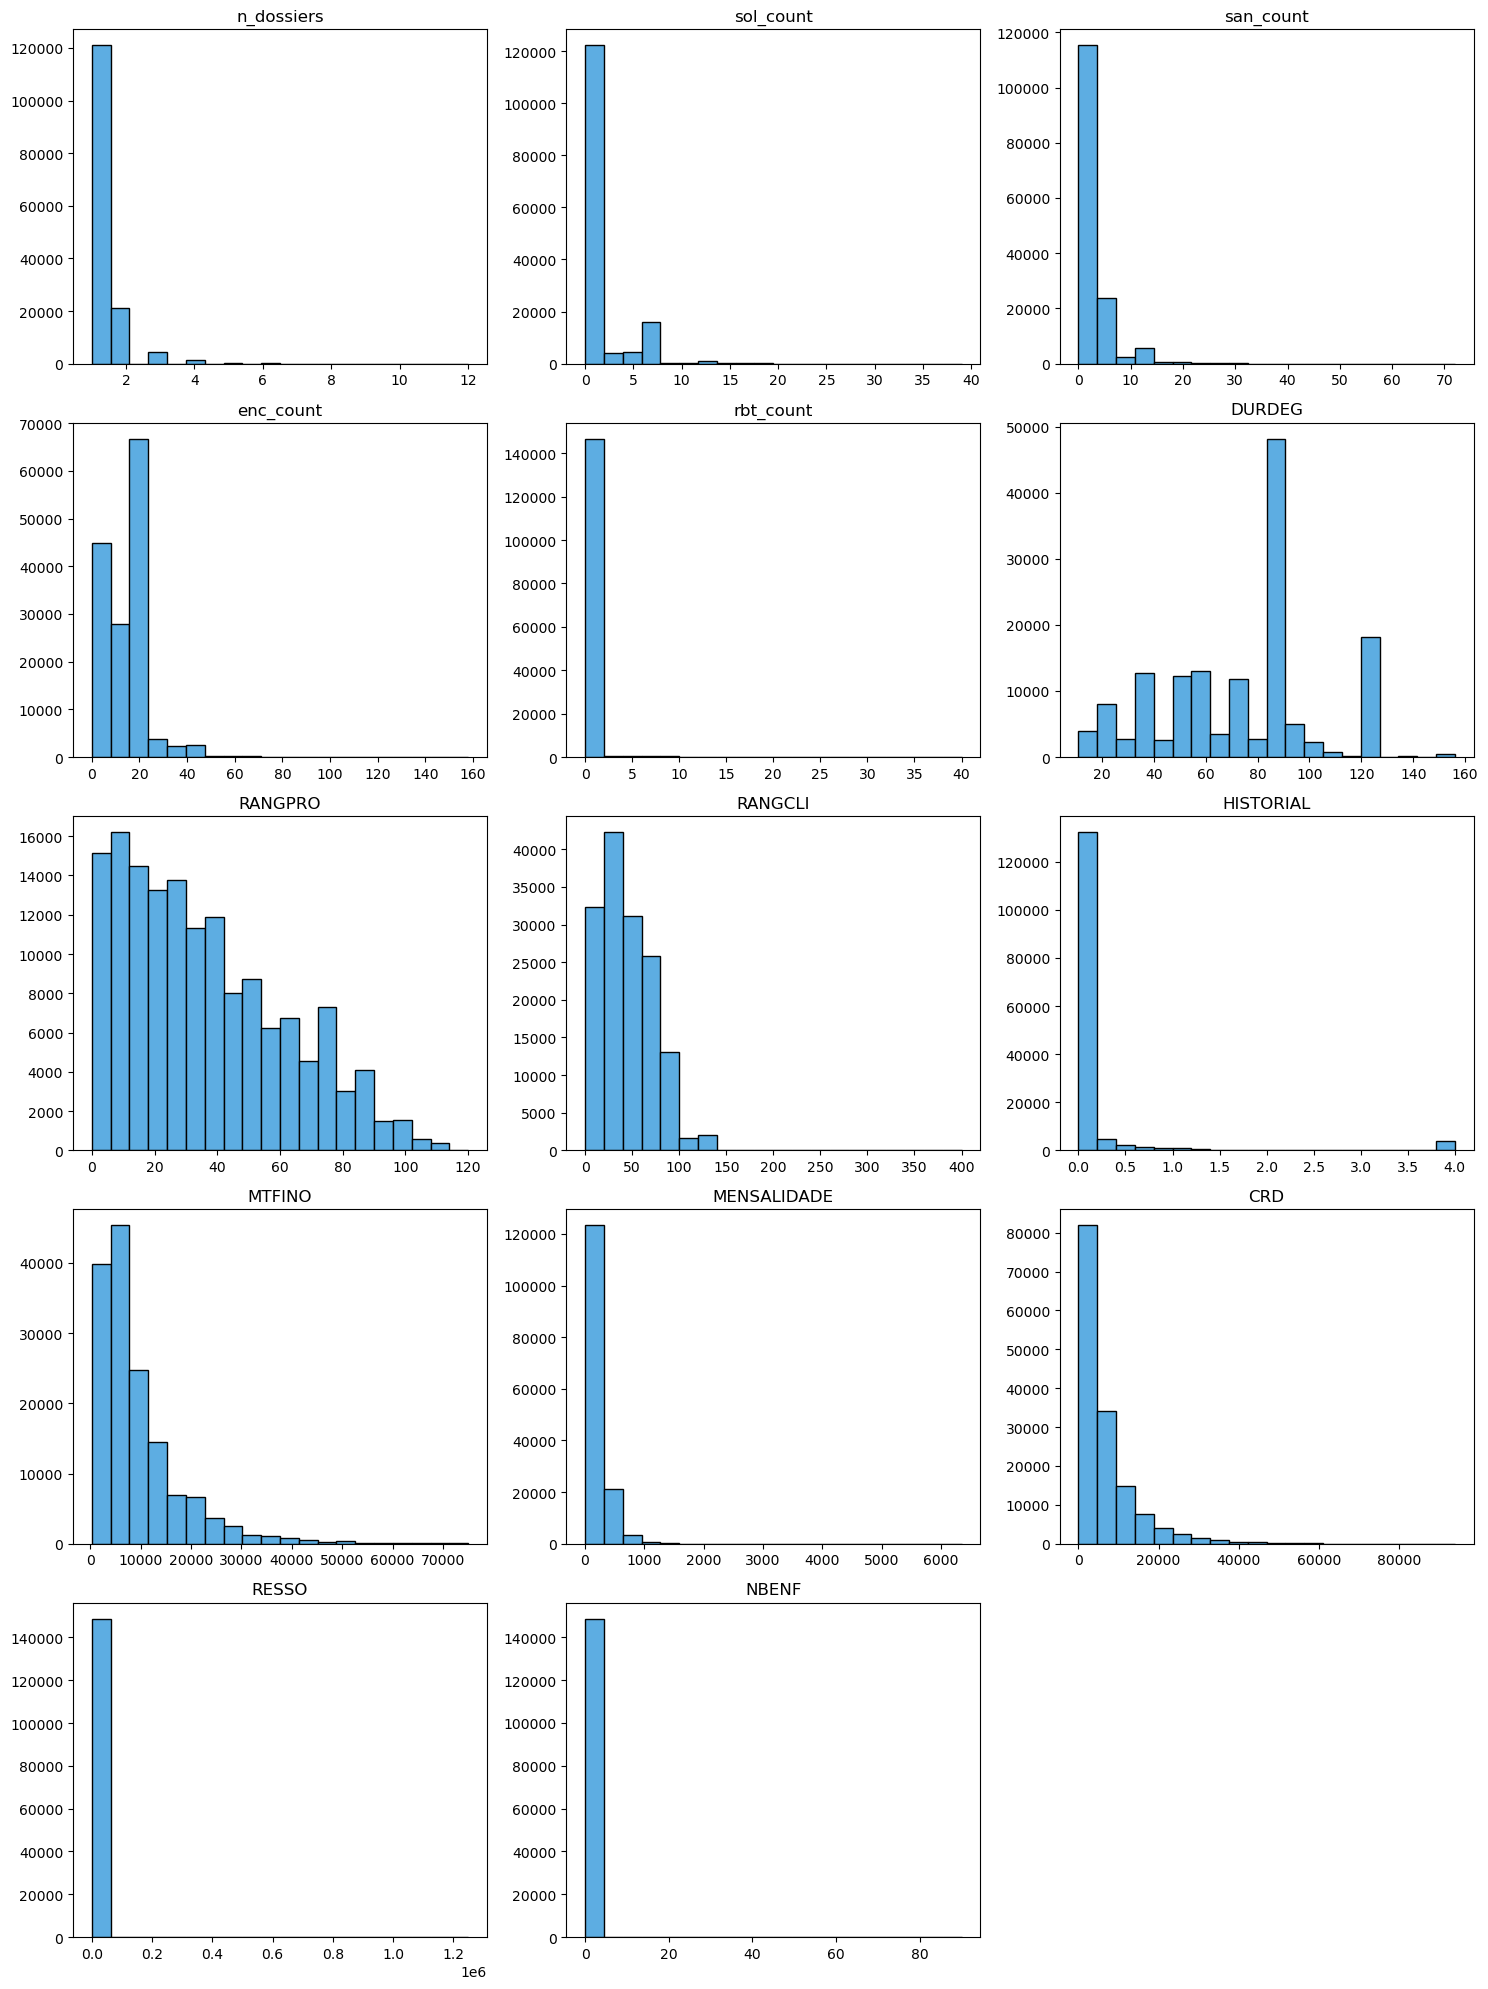

In [32]:
n = len(num_cols)
fig, axes = plt.subplots(nrows = (n // 3) + 1, ncols = 3, figsize = (15, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(agg_clients_num[col].dropna(), bins = 20, color = '#5dade2', edgecolor = 'black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    #axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

C:\Users\nicol\AppData\Local\Temp\ipykernel_4452\1031368143.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[feat] = pd.to_numeric(data[feat], errors="coerce")
C:\Users\nicol\AppData\Local\Temp\ipykernel_4452\1031368143.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[feat] = pd.to_numeric(data[feat], errors="coerce")
C:\Users\nicol\AppData\Local\Temp\ipykernel_4452\1031368143.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

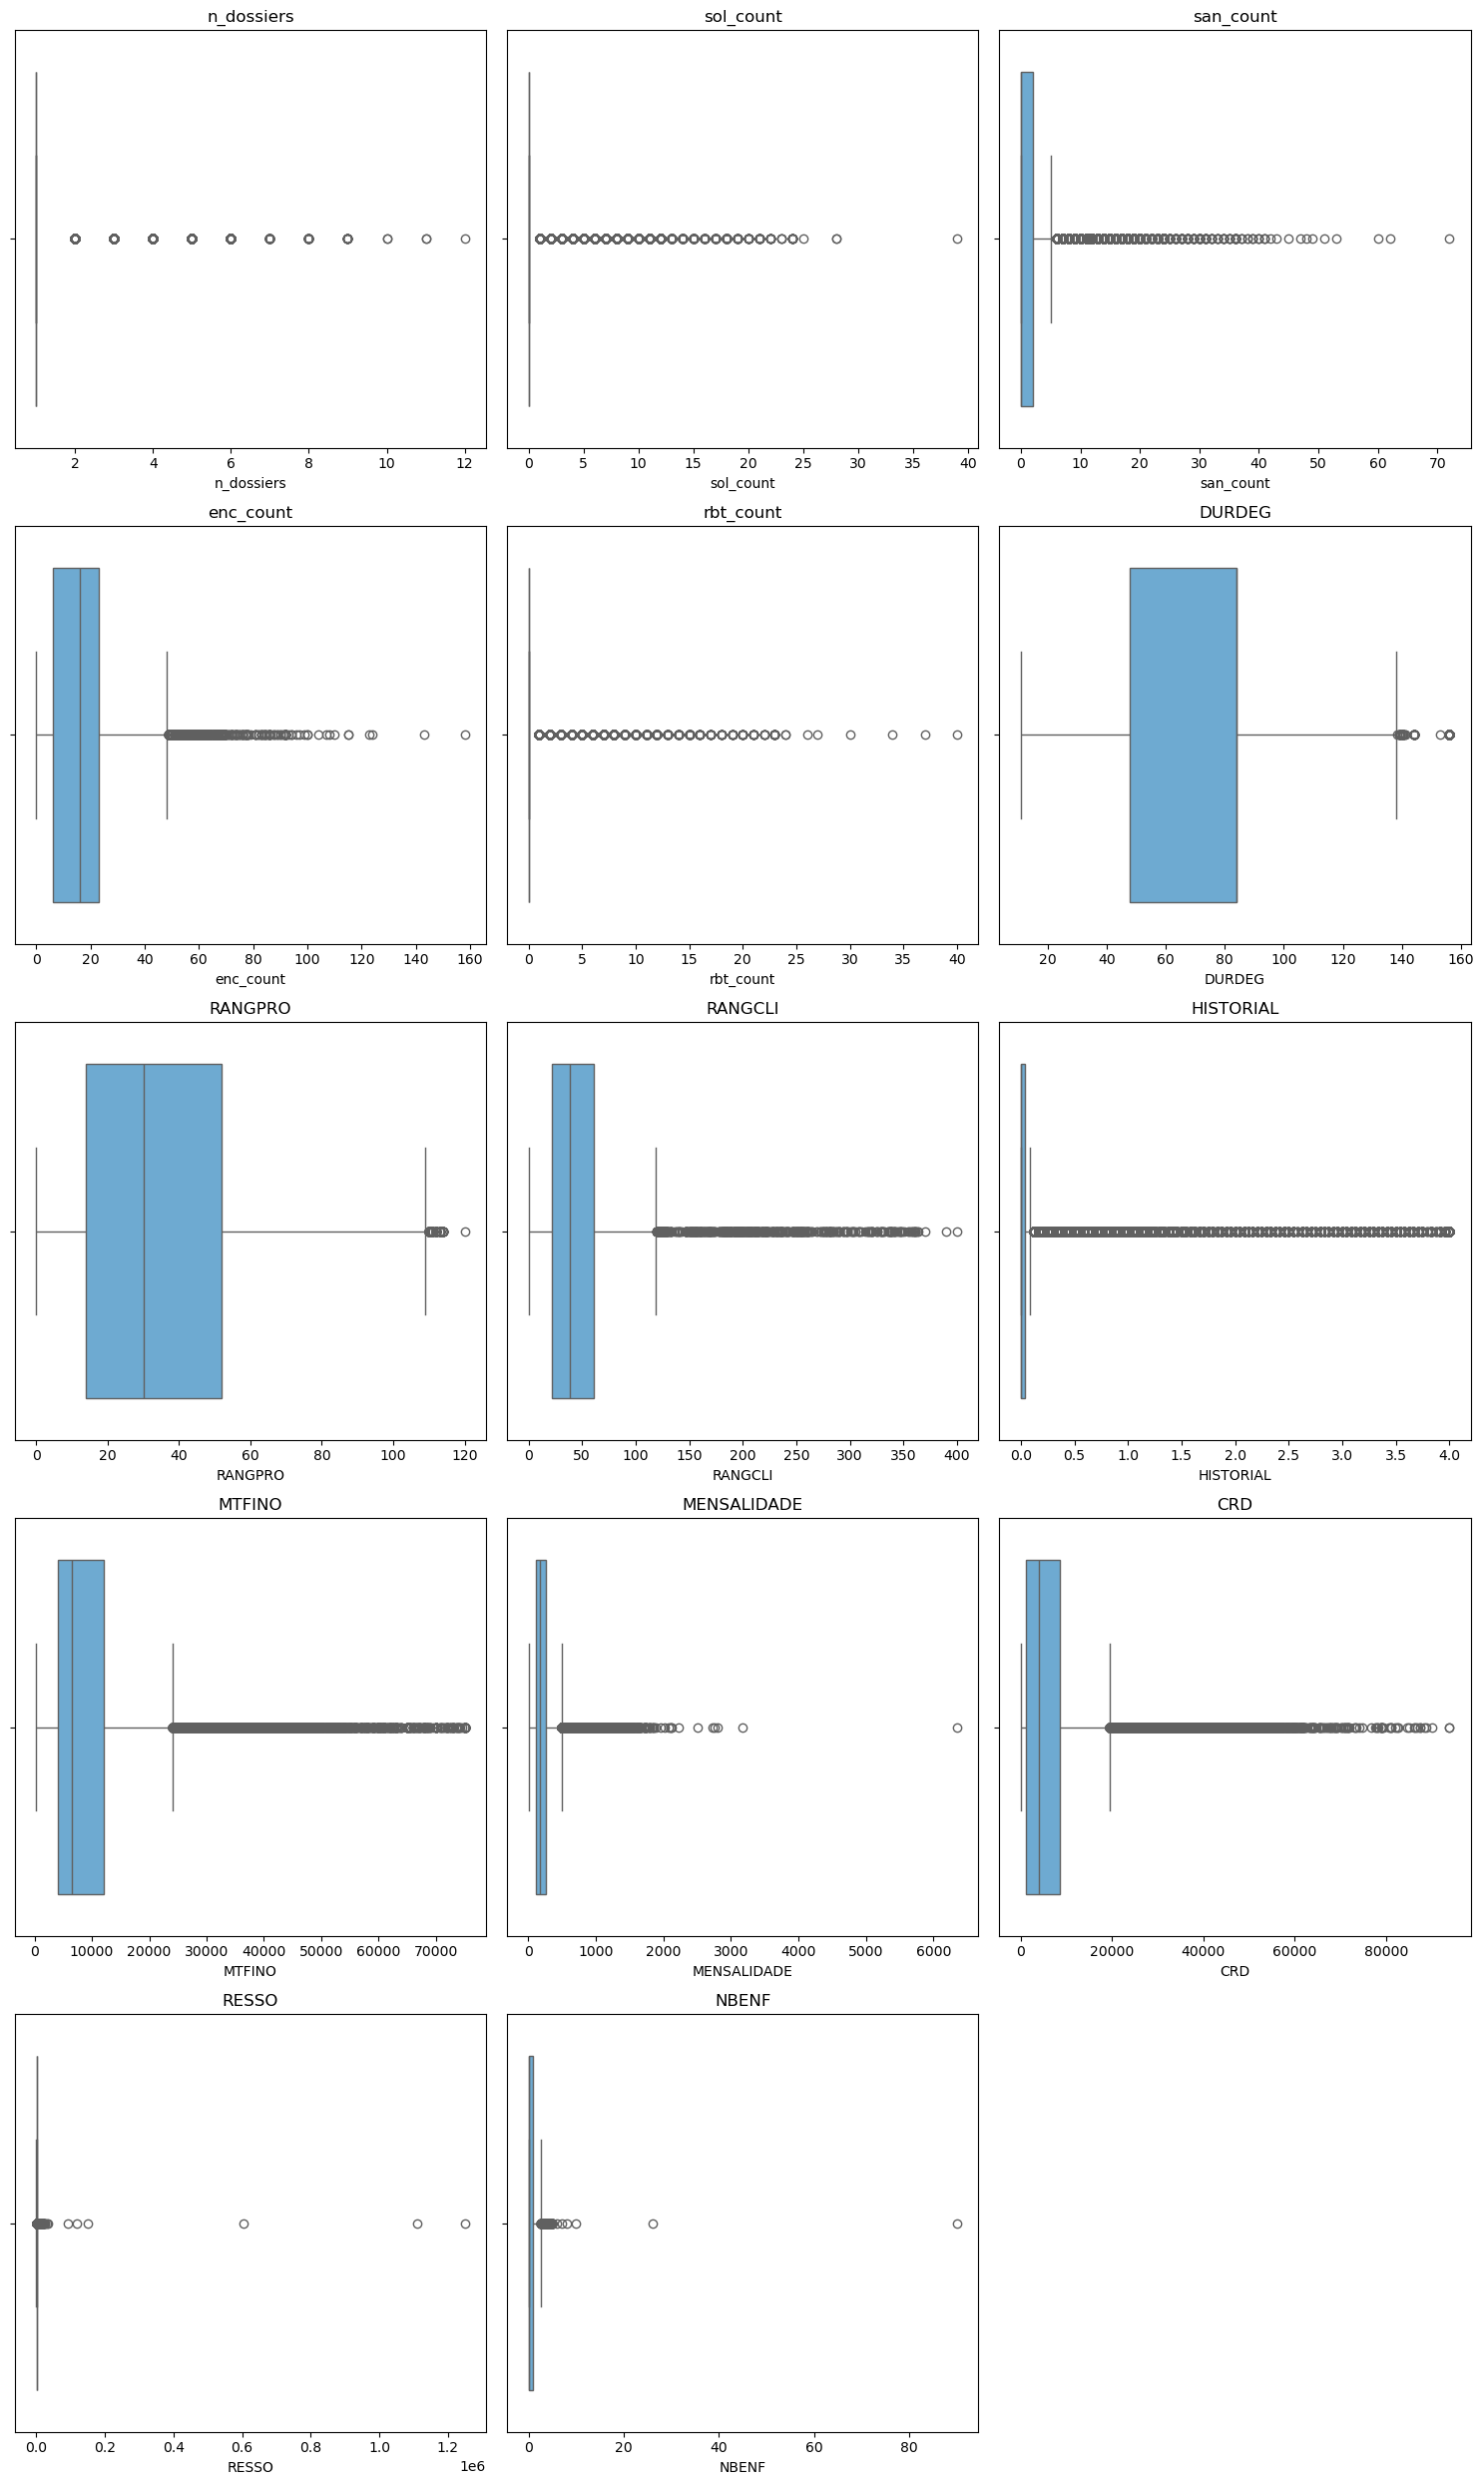

In [33]:
def plot_multiple_boxplots(data, feats):
    
    n = len(feats)  # número de features
    ncols = 3
    nrows = (n // ncols) + (n % ncols > 0)
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 5*nrows))
    axes = axes.flatten()
    
    for i, feat in enumerate(feats):
        # garantir que é numérica
        data[feat] = pd.to_numeric(data[feat], errors="coerce")
        
        # remover NaNs para evitar erro
        clean_data = data[feat].dropna()
        
        if len(clean_data) > 0:
            sns.boxplot(x=clean_data, ax=axes[i], color="#5dade2")
            axes[i].set_title(feat)
        else:
            axes[i].set_visible(False)
    
    # remover eixos extra
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
#    plt.suptitle(title, fontsize=20)
    plt.tight_layout()
    plt.show()

plot_multiple_boxplots(agg_clients_num, num_cols)

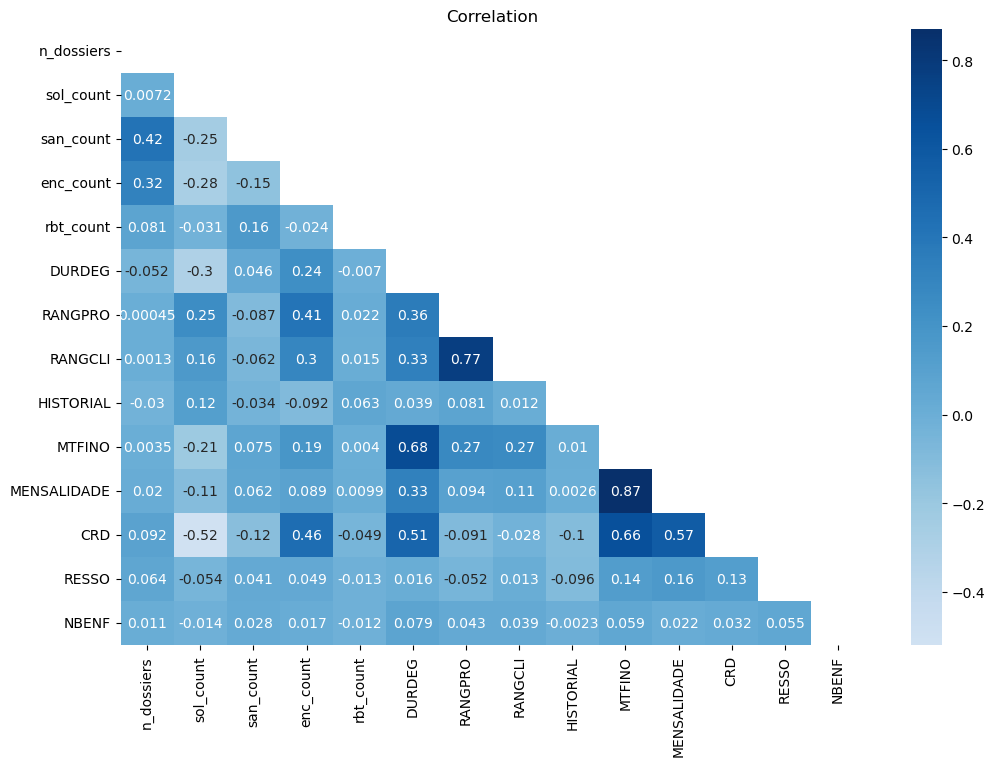

In [34]:
cor_spearman = agg_clients_num.corr(method ='spearman')
#mask = (cor_spearman.abs() < 0.5)
mask = np.triu(np.ones_like(cor_spearman, dtype=bool))

plt.figure(figsize=(12,8))
sns.heatmap(cor_spearman, 
            annot=True, 
            mask=mask,
            cmap = "Blues", 
            center=0)

plt.title("Correlation")
plt.show()

### Treating missing values

In [35]:
agg_clients_num.isna().sum()

n_dossiers      0
sol_count       0
san_count       0
enc_count       0
rbt_count       0
DURDEG          0
RANGPRO         0
RANGCLI         0
HISTORIAL       0
MTFINO          0
MENSALIDADE     0
CRD             0
RESSO           0
NBENF          40
dtype: int64

In [36]:
pd.set_option('display.max_columns', None)
agg_clients[agg_clients['RANGCLI'] == 400]


,n_dossiers,sol_count,san_count,enc_count,rbt_count,DURDEG,MTFINO,MENSALIDADE,RANGPRO,RANGCLI,HISTORIAL,CRD,RESSO,NBENF,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO
CONTRIB,,,,,,,,,,,,,,,,,,,,
f51344fd4cb7a2d8c74abbfe3dc7e578609caa6b2f09dc6c45d11fdd2f35a2a8,1,0,0,23,0,72.0,5500.0,125.022187,31,400,0.0,5125.236,1541.042,0.0,117.0,P,90.0,P,4350,A


In [37]:
agg_clients_num[agg_clients_num['RANGPRO'] == agg_clients_num['RANGCLI']]

,n_dossiers,sol_count,san_count,enc_count,rbt_count,DURDEG,RANGPRO,RANGCLI,HISTORIAL,MTFINO,MENSALIDADE,CRD,RESSO,NBENF
CONTRIB,,,,,,,,,,,,,,
0000ab2116257783438c70ff85a3e98f2d4194ebe534349a33373dfcb3a3a297,1,0,0,23,0,120.0,91,91,0.000000,20000.000,347.447280,10712.816261,1113.258,1.0
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,2,12,0,0,0,60.0,21,21,4.000000,9726.555,304.456898,0.000000,678.483,2.0
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,1,0,12,0,0,72.0,34,34,0.333333,2500.000,56.017772,0.000000,838.186,0.0
0000f858346061c53064586a3347b34659565a6712d004e64309c2473f76faed,1,0,0,23,0,84.0,74,74,0.000000,5000.000,100.073575,1787.872609,1314.144,2.0
000406feeb8088e3b05f47bc89160d25ca14f11c31f91bc6516a4e6753e58d73,1,6,0,0,0,84.0,24,24,4.000000,12000.000,274.916857,0.000000,797.805,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fffb0b5e039cf837e38c5abe51fb5d9db7366c12609d566f8b44ef3f8a12a349,1,0,0,23,0,120.0,59,59,0.000000,12500.000,216.051740,10714.015739,957.059,0.0
fffbc66ca4256976c9932916770f1ff3b23aacce5998ffc7d570a73378d619df,2,6,0,35,0,78.0,83,83,0.416667,4965.000,107.103288,954.311703,977.381,1.0
fffc47b191b25cbc3dbc9ce436b94e52d2084144ee5bec31fd2457f3cff87c3c,1,0,0,7,0,36.0,6,6,0.083333,2000.000,81.856368,2163.063429,0.000,2.0


In [38]:
agg_clients_num[agg_clients_num['rbt_count'] == 40]

,n_dossiers,sol_count,san_count,enc_count,rbt_count,DURDEG,RANGPRO,RANGCLI,HISTORIAL,MTFINO,MENSALIDADE,CRD,RESSO,NBENF
CONTRIB,,,,,,,,,,,,,,
a7694a908823a9d442bc440d46fe935d580c605edcc4057992e852b4f969f6da,3,0,0,26,40,76.0,24,61,0.0,23950.86,531.20642,12909.228134,2774.367174,0.0


In [39]:
from sklearn.impute import KNNImputer

knn = KNNImputer(n_neighbors = 5, weights = 'distance')
agg_clients_num['NBENF'] = knn.fit_transform(agg_clients_num)

C:\Users\nicol\AppData\Local\Temp\ipykernel_4452\2541374680.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_clients_num['NBENF'] = knn.fit_transform(agg_clients_num)


In [40]:
agg_clients_num.isna().sum()

n_dossiers     0
sol_count      0
san_count      0
enc_count      0
rbt_count      0
DURDEG         0
RANGPRO        0
RANGCLI        0
HISTORIAL      0
MTFINO         0
MENSALIDADE    0
CRD            0
RESSO          0
NBENF          0
dtype: int64

In [ ]:
agg_clients_cat

In [41]:
for col in agg_clients_cat.columns:
    print(agg_clients_cat[col].value_counts())

AGFIN
118.0    65306
117.0    41203
120.0    32209
119.0     8308
525.0     1481
112.0      201
111.0       11
500.0        7
116.0        1
503.0        1
100.0        1
Name: count, dtype: int64
PAGAMENTO
P    146359
N      2369
M         1
Name: count, dtype: int64
CSP
80.0    44349
60.0    31826
70.0    13496
31.0    13122
90.0     5363
74.0     4003
15.0     3713
35.0     3663
56.0     3650
32.0     3458
91.0     3304
20.0     2756
30.0     2654
41.0     2250
92.0     1449
33.0     1209
50.0     1095
10.0      888
54.0      885
81.0      798
86.0      798
57.0      743
55.0      673
52.0      656
40.0      573
58.0      535
53.0      313
34.0      202
25.0      104
96.0       96
99.0       72
0.0        18
51.0       15
Name: count, dtype: int64
NATIO
P    147069
D       889
C       770
X         1
Name: count, dtype: int64
PTT
2735    1750
2910    1716
4430    1619
2725    1527
4435    1404
        ... 
2838       1
6158       1
4424       1
6021       1
1850       1
Name: count,

In [ ]:
agg_clients_cat.isna().sum()

In [ ]:
agg_clients_cat['MODCONTACTO'].value_counts()

In [42]:
agg_clients_cat['MODCONTACTO'].fillna(agg_clients_cat['MODCONTACTO'].mode()[0], inplace=True)

C:\Users\nicol\AppData\Local\Temp\ipykernel_4452\2262050263.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  agg_clients_cat['MODCONTACTO'].fillna(agg_clients_cat['MODCONTACTO'].mode()[0], inplace=True)
C:\Users\nicol\AppData\Local\Temp\ipykernel_4452\2262050263.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agg_clients_cat['MODCONTACT

In [ ]:
agg_clients_cat.isna().sum()

### Categorical Features

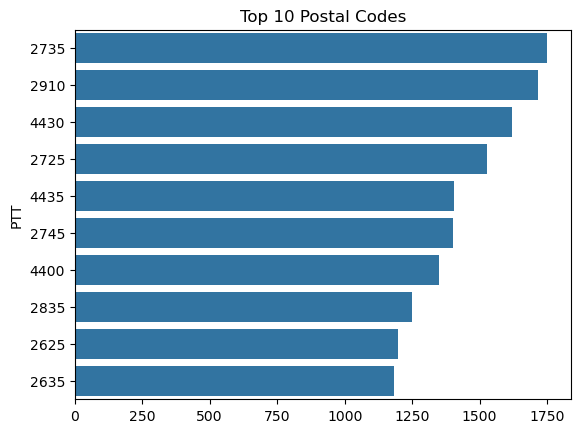

In [43]:
top_postal = agg_clients_cat['PTT'].value_counts().nlargest(10)

sns.barplot(x = top_postal.values, y = top_postal.index)
plt.title('Top 10 Postal Codes')
plt.show()

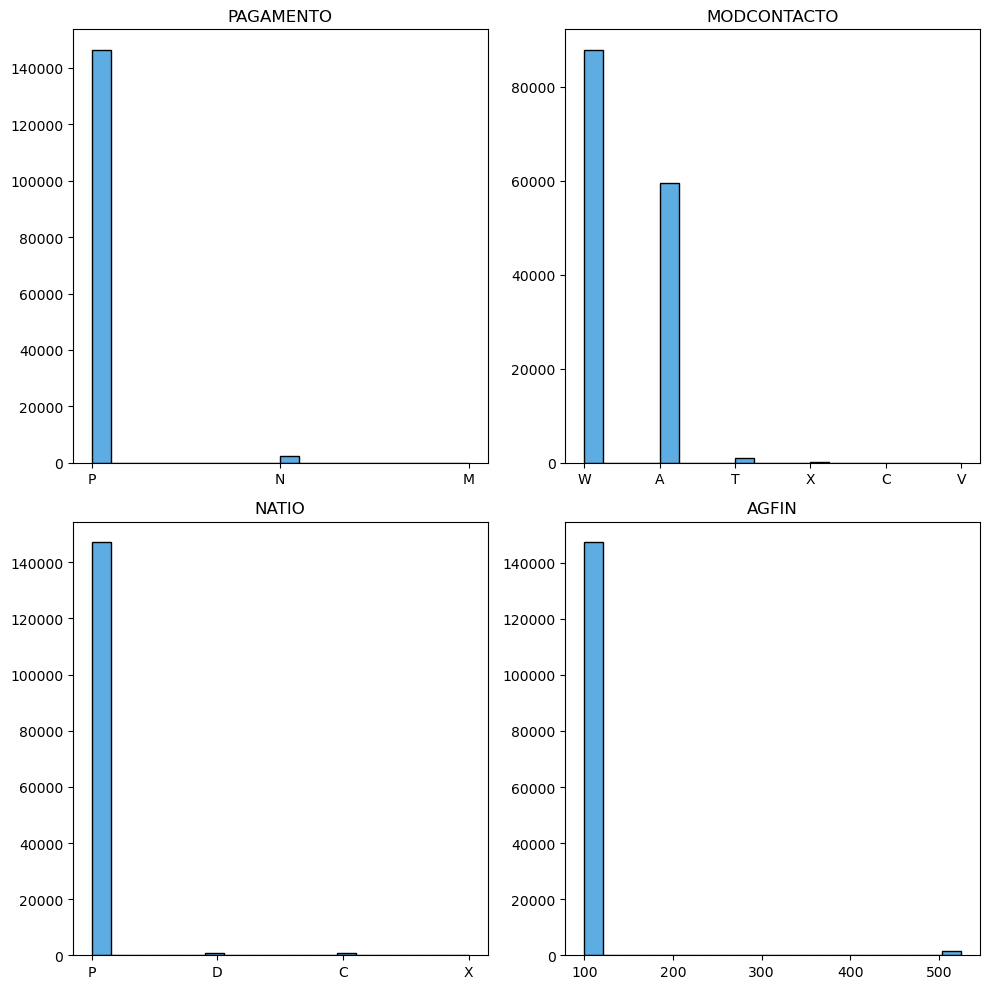

In [44]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (10, 10))
axes = axes.flatten()
cols = ['PAGAMENTO', 'MODCONTACTO', 'NATIO', 'AGFIN']
for i, col in enumerate(cols):
    axes[i].hist(agg_clients_cat[col].dropna(), bins = 20, color = '#5dade2', edgecolor = 'black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    #axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
top_csp = agg_clients_cat['CSP'].value_counts().nlargest(5)

sns.barplot(x = top_csp.values, y = top_csp.index)
plt.title('Top 5 CSP')
plt.show()

criar uma dataframe separada para cada filtro (SAN e SOL)

In [ ]:
SAN = BDOSS[BDOSS['POS'] == 'SAN']
SOL = BDOSS[BDOSS['POS'] == 'SOL']

In [ ]:
SAN.describe(include='all').T

In [ ]:
SAN.info()